##  Objective
This notebook builds an XGBoost model to predict future stock returns for a major tech stock and convert those predictions into practical investor decisions.

Instead of only asking which stock is best, this notebook also asks:

- Should an investor buy this stock?
- Should the investor avoid it because it may generate a loss?
- If we follow the model’s signals, what profit or loss do we get?

This makes the project more useful for a real stakeholder such as an individual investor or small portfolio manager.

# 1. Problem Statement

Retail investors often struggle with two questions:

1. Which stock is likely to perform well in the near future?
2. Which stock is likely to underperform and should be avoided?

Our original project focused on predicting and ranking five major tech stocks:
- Apple
- Microsoft
- Google
- Amazon
- Nvidia

However, based on instructor feedback, ranking alone is not enough. A useful investor-facing system should also provide clear action guidance and estimate the financial outcome of using that guidance.

Because of that, this notebook reframes the problem as both:
- a **forecasting problem**, and
- a **decision-support problem**.

# 2. Stakeholder Need

The main stakeholder is an individual investor.

This stakeholder does not only want a predicted return number. They want guidance that helps with action:

- buy stocks with strong expected returns,
- avoid stocks with weak or negative expected returns,
- and reduce poor decisions that may lead to loss.

So, the goal of this notebook is not just to predict returns, but to evaluate whether those predictions are useful for making better decisions.

# 3. Why XGBoost?

XGBoost is a strong model for this task because it can learn nonlinear relationships from structured tabular data.

In stock prediction, future returns may depend on interactions between:
- momentum,
- trend,
- volatility,
- and trading activity.

XGBoost is a good fit because it can model those interactions better than a simple baseline and can also provide feature importance for interpretation.

# 4. Modeling Plan

This notebook follows these steps:

1. Load stock data
2. Clean and sort the data
3. Create time-series features
4. Define the future return target
5. Split data by time into training, validation, and test sets
6. Train an XGBoost regressor
7. Evaluate predictive accuracy
8. Convert predictions into buy / hold / avoid signals
9. Estimate profit/loss from those signals
10. Interpret whether the model is useful for the stakeholder

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# 5. Load the Data

We begin with one stock first so that the modeling workflow is easy to validate before expanding it to all five stocks.

This notebook can later be reused for:
- AAPL
- MSFT
- GOOGL
- AMZN
- NVDA

In [12]:
# Change the filename here depending on which stock you want to test first
import pandas as pd

# Load the Google stock dataset
google_df = pd.read_csv("../../data/Google.csv")

# Clean column names by removing hidden spaces
google_df.columns = google_df.columns.str.replace('\xa0', '', regex=False).str.strip()

print("Google dataset shape:", google_df.shape)
print("Google columns:", google_df.columns.tolist())

google_df.head()

Google dataset shape: (2805, 7)
Google columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2/27/2026,303.94,312.08,303.59,311.43,311.43,"33,389,200"
1,2/26/2026,312.80,313.00,302.41,307.15,307.15,"22,380,000"
2,2/25/2026,312.12,313.66,309.36,313.03,313.03,"20,209,100"
3,2/24/2026,310.64,312.37,306.09,310.92,310.92,"15,040,700"
4,2/23/2026,319.14,319.45,309.99,311.69,311.69,"17,641,200"


##  Clean the Dataset

The raw Google CSV contains formatting issues such as hidden spaces in column names and commas in the volume column.  
We clean those issues before modeling.

In [13]:
# Convert the Date column to datetime format
google_df['Date'] = pd.to_datetime(google_df['Date'])

# Convert the main price columns to numeric values
price_cols = ['Open', 'High', 'Low', 'Close']
for col in price_cols:
    google_df[col] = pd.to_numeric(google_df[col], errors='coerce')

# Convert Volume to numeric
google_df['Volume'] = google_df['Volume'].astype(str).str.replace(',', '', regex=False)
google_df['Volume'] = pd.to_numeric(google_df['Volume'], errors='coerce')

# Keep only the columns needed for this model
google_df = google_df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Sort the dataset from oldest to newest date
google_df = google_df.sort_values('Date').reset_index(drop=True)

# Drop rows with missing values
google_df = google_df.dropna().reset_index(drop=True)

print(google_df.dtypes)
print(google_df.shape)

google_df.head()

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object
(2805, 6)


,Date,Open,High,Low,Close,Volume
0,2015-01-02,26.63,26.79,26.39,26.48,26480000
1,2015-01-05,26.36,26.40,25.89,25.97,41182000
2,2015-01-06,26.02,26.06,25.28,25.33,54456000
3,2015-01-07,25.55,25.57,25.18,25.26,46918000
4,2015-01-08,25.08,25.38,24.75,25.35,73054000


## 3. Verify the Cleaned Data

In [22]:
# Display column names
print(google_df.columns.tolist())

# Check for missing values in each column
print(google_df.isna().sum())

# Preview the cleaned dataset
google_df.head()

['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'close_lag_1', 'close_lag_7', 'close_lag_30', 'return_1d', 'return_7d', 'return_30d', 'ma_7', 'ma_30', 'ma_200', 'volatility_7', 'volatility_30', 'volume_change_1d', 'volume_ma_7', 'volume_ma_30', 'rsi_14', 'target_7d']
Date                0
Open                0
High                0
Low                 0
Close               0
Volume              0
close_lag_1         0
close_lag_7         0
close_lag_30        0
return_1d           0
return_7d           0
return_30d          0
ma_7                0
ma_30               0
ma_200              0
volatility_7        0
volatility_30       0
volume_change_1d    0
volume_ma_7         0
volume_ma_30        0
rsi_14              0
target_7d           0
dtype: int64


,Date,Open,High,Low,Close,Volume,close_lag_1,close_lag_7,close_lag_30,return_1d,...,ma_7,ma_30,ma_200,volatility_7,volatility_30,volume_change_1d,volume_ma_7,volume_ma_30,rsi_14,target_7d
0,2015-10-16,34.77,34.81,34.46,34.77,36316000,34.65,33.50,31.85,0.003463,...,34.047143,32.951000,29.23655,0.008079,0.013539,-0.229875,3.647514e+07,4.065173e+07,89.910314,0.053782
1,2015-10-19,34.70,35.01,34.61,35.00,30172000,34.77,33.35,31.45,0.006615,...,34.282857,33.069333,29.27915,0.006817,0.013227,-0.169182,3.517000e+07,4.030820e+07,91.973970,0.052857
2,2015-10-20,34.89,34.90,33.68,34.00,52434000,35.00,33.56,32.19,-0.028571,...,34.345714,33.129667,29.31930,0.015089,0.013930,0.737836,3.807143e+07,4.075293e+07,71.576763,0.095294
3,2015-10-21,34.16,34.24,33.53,33.59,31952000,34.00,33.82,32.17,-0.012059,...,34.312857,33.177000,29.36060,0.015669,0.014156,-0.390624,3.882400e+07,4.045207e+07,64.752475,0.097648
4,2015-10-22,33.77,34.40,33.58,34.06,88632000,33.59,34.16,32.55,0.013992,...,34.298571,33.227333,29.40460,0.016188,0.014216,1.773911,4.542200e+07,4.247813e+07,62.683438,0.097769


## 4. Feature Engineering

We create trend, momentum, volatility, and volume features so the model can learn stock behavior more effectively.

In [15]:
# Create lag features
google_df['close_lag_1'] = google_df['Close'].shift(1)
google_df['close_lag_7'] = google_df['Close'].shift(7)
google_df['close_lag_30'] = google_df['Close'].shift(30)

# Create return-based features
google_df['return_1d'] = google_df['Close'].pct_change(1)
google_df['return_7d'] = google_df['Close'].pct_change(7)
google_df['return_30d'] = google_df['Close'].pct_change(30)

# Create moving averages
google_df['ma_7'] = google_df['Close'].rolling(7).mean()
google_df['ma_30'] = google_df['Close'].rolling(30).mean()
google_df['ma_200'] = google_df['Close'].rolling(200).mean()

# Create volatility features
google_df['volatility_7'] = google_df['return_1d'].rolling(7).std()
google_df['volatility_30'] = google_df['return_1d'].rolling(30).std()

# Create volume-based features
google_df['volume_change_1d'] = google_df['Volume'].pct_change(1)
google_df['volume_ma_7'] = google_df['Volume'].rolling(7).mean()
google_df['volume_ma_30'] = google_df['Volume'].rolling(30).mean()

google_df.head()

,Date,Open,High,Low,Close,Volume,close_lag_1,close_lag_7,close_lag_30,return_1d,return_7d,return_30d,ma_7,ma_30,ma_200,volatility_7,volatility_30,volume_change_1d,volume_ma_7,volume_ma_30
0,2015-01-02,26.63,26.79,26.39,26.48,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,26.36,26.40,25.89,25.97,41182000,26.48,NaN,NaN,-0.019260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.555211,NaN,NaN
2,2015-01-06,26.02,26.06,25.28,25.33,54456000,25.97,NaN,NaN,-0.024644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.322325,NaN,NaN
3,2015-01-07,25.55,25.57,25.18,25.26,46918000,25.33,NaN,NaN,-0.002764,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.138424,NaN,NaN
4,2015-01-08,25.08,25.38,24.75,25.35,73054000,25.26,NaN,NaN,0.003563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.557057,NaN,NaN


## 5. Add the RSI Feature

In [23]:
# Define a function to compute the Relative Strength Index (RSI)
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Add RSI as a feature for Google stock
google_df['rsi_14'] = compute_rsi(google_df['Close'], 14)

# Preview RSI values
google_df[['Date', 'Close', 'rsi_14']].head(20)

,Date,Close,rsi_14
0,2015-10-16,34.77,NaN
1,2015-10-19,35.00,NaN
2,2015-10-20,34.00,NaN
3,2015-10-21,33.59,NaN
4,2015-10-22,34.06,NaN
5,2015-10-23,35.97,NaN
6,2015-10-26,36.56,NaN
7,2015-10-27,36.64,NaN
8,2015-10-28,36.85,NaN
9,2015-10-29,37.24,NaN


## 6. Define the Target Variable
The target variable for this model is the 7-day future return. This means the model learns to predict how much the stock price will change over the next 7 trading days.

In [24]:
# Create the 7-day future return target
google_df['target_7d'] = (google_df['Close'].shift(-7) - google_df['Close']) / google_df['Close']

# Drop rows with missing values caused by rolling windows and shifting
google_df = google_df.dropna().reset_index(drop=True)

# Check the dataset after target creation
print("Google dataset shape after target creation:", google_df.shape)

# Preview the final modeling dataset
google_df.head()

Google dataset shape after target creation: (2579, 22)


,Date,Open,High,Low,Close,Volume,close_lag_1,close_lag_7,close_lag_30,return_1d,...,ma_7,ma_30,ma_200,volatility_7,volatility_30,volume_change_1d,volume_ma_7,volume_ma_30,rsi_14,target_7d
0,2015-11-04,37.49,37.99,37.46,37.77,41840000,37.44,36.56,32.66,0.008814,...,37.171429,34.411333,29.92890,0.007883,0.016462,0.152427,3.899229e+07,4.510827e+07,72.865854,-0.020387
1,2015-11-05,37.94,38.32,37.87,38.03,45486000,37.77,36.64,32.75,0.006884,...,37.370000,34.587333,29.98475,0.007834,0.016460,0.087141,3.995057e+07,4.533473e+07,73.900293,-0.013410
2,2015-11-06,37.97,38.15,37.75,38.08,33544000,38.03,36.85,32.01,0.001315,...,37.545714,34.789667,30.03965,0.007976,0.015629,-0.262542,3.908486e+07,4.483687e+07,73.192771,-0.020483
3,2015-11-09,37.93,38.17,37.46,37.74,35538000,38.08,37.24,31.21,-0.008929,...,37.617143,35.007333,30.09415,0.008940,0.014786,0.059444,3.894457e+07,4.443327e+07,81.270903,0.006889
4,2015-11-10,37.67,38.03,37.42,37.91,29798000,37.74,36.87,31.13,0.004505,...,37.765714,35.233333,30.15340,0.007249,0.014693,-0.161517,3.748943e+07,4.402220e+07,87.630662,0.002374


## 7. Select Features and Split the Data

We use a time-based split to avoid data leakage. Training data contains records before 2024, validation data contains records from 2024, and test data contains records from 2025 onward.

In [25]:
# Define the feature columns used in the Google XGBoost model
google_features = [
    'close_lag_1', 'close_lag_7', 'close_lag_30',
    'return_1d', 'return_7d', 'return_30d',
    'ma_7', 'ma_30', 'ma_200',
    'volatility_7', 'volatility_30',
    'volume_change_1d', 'volume_ma_7', 'volume_ma_30',
    'rsi_14'
]

# Split the dataset into train, validation, and test sets based on time
google_train_df = google_df[google_df['Date'] < '2024-01-01']
google_val_df = google_df[(google_df['Date'] >= '2024-01-01') & (google_df['Date'] < '2025-01-01')]
google_test_df = google_df[google_df['Date'] >= '2025-01-01']

# Create feature matrices and target vectors
google_X_train = google_train_df[google_features]
google_y_train = google_train_df['target_7d']

google_X_val = google_val_df[google_features]
google_y_val = google_val_df['target_7d']

google_X_test = google_test_df[google_features]
google_y_test = google_test_df['target_7d']

# Print the size of each split
print("Google train shape:", google_X_train.shape)
print("Google validation shape:", google_X_val.shape)
print("Google test shape:", google_X_test.shape)

Google train shape: (2052, 15)
Google validation shape: (252, 15)
Google test shape: (275, 15)


## 8. Train the Google XGBoost Model

In [26]:
from sklearn import set_config
from xgboost import XGBRegressor

# Turn off rich display formatting for cleaner notebook output
set_config(display="text")

# Define the Google XGBoost regressor with chosen hyperparameters
google_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Train the model on the Google training data
_ = google_model.fit(google_X_train, google_y_train)

print("Google model trained successfully.")

Google model trained successfully.


## 9. Generate Google Predictions

In [27]:
# Generate predictions for validation and test sets
google_val_preds = google_model.predict(google_X_val)
google_test_preds = google_model.predict(google_X_test)

# Check prediction output
print("Google validation predictions shape:", google_val_preds.shape)
print("Google test predictions shape:", google_test_preds.shape)
print("First 5 Google validation predictions:", google_val_preds[:5])

Google validation predictions shape: (252,)
Google test predictions shape: (275,)
First 5 Google validation predictions: [-0.01639168 -0.0320706  -0.02394535 -0.02456318 -0.01387773]


## 10. Regression Evaluation


The XGBoost model is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Compute validation error metrics
google_val_mae = mean_absolute_error(google_y_val, google_val_preds)
google_val_rmse = np.sqrt(mean_squared_error(google_y_val, google_val_preds))

# Compute test error metrics
google_test_mae = mean_absolute_error(google_y_test, google_test_preds)
google_test_rmse = np.sqrt(mean_squared_error(google_y_test, google_test_preds))

# Print evaluation results
print("Google Validation MAE:", google_val_mae)
print("Google Validation RMSE:", google_val_rmse)
print("Google Test MAE:", google_test_mae)
print("Google Test RMSE:", google_test_rmse)

Google Validation MAE: 0.06523007741577748
Google Validation RMSE: 0.07580484775662749
Google Test MAE: 0.0745696052260931
Google Test RMSE: 0.08742045915919776


## 11. Directional Accuracy

Directional accuracy measures how often the model correctly predicts whether the future return is positive or negative.

In [30]:
# Compute directional accuracy on validation and test data
google_val_direction_acc = np.mean((google_val_preds > 0) == (google_y_val > 0))
google_test_direction_acc = np.mean((google_test_preds > 0) == (google_y_test > 0))

# Print directional accuracy results
print("Google Validation Directional Accuracy:", google_val_direction_acc)
print("Google Test Directional Accuracy:", google_test_direction_acc)

Google Validation Directional Accuracy: 0.3888888888888889
Google Test Directional Accuracy: 0.38181818181818183


## 12. Actual vs Predicted Google Returns

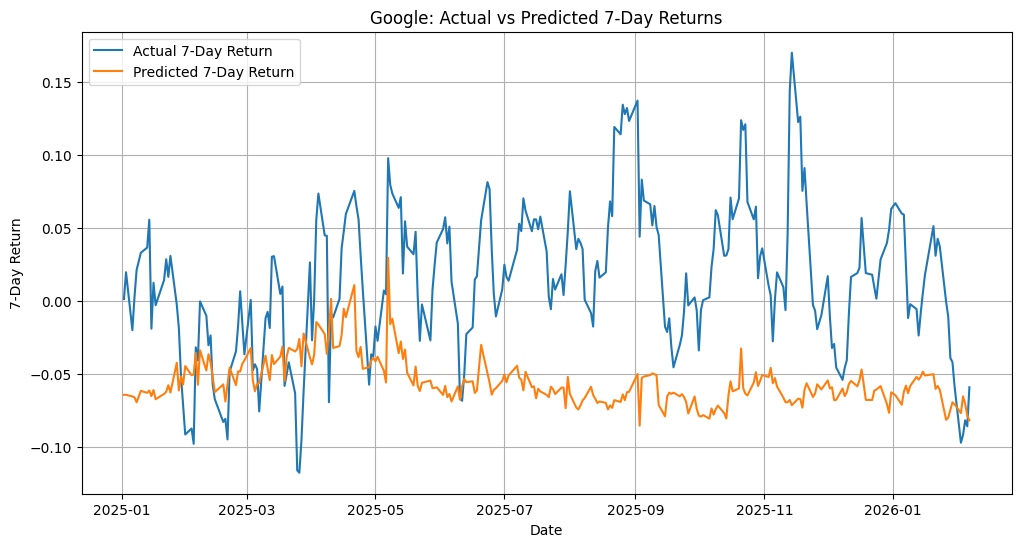

In [31]:
import matplotlib.pyplot as plt

# Create a results dataframe for Google test predictions
google_results = google_test_df[['Date', 'target_7d']].copy()
google_results['predicted_7d'] = google_test_preds

# Plot actual vs predicted 7-day returns
plt.figure(figsize=(12, 6))
plt.plot(google_results['Date'], google_results['target_7d'], label='Actual 7-Day Return')
plt.plot(google_results['Date'], google_results['predicted_7d'], label='Predicted 7-Day Return')
plt.title('Google: Actual vs Predicted 7-Day Returns')
plt.xlabel('Date')
plt.ylabel('7-Day Return')
plt.legend()
plt.grid(True)
plt.show()

## 13. Convert Google Predictions into Buy / Hold / Avoid Signals

Predicted returns are converted into simple investment signals. Positive predicted returns above 2% are labeled as Buy, values between 0% and 2% are labeled as Hold, and negative predictions are labeled as Avoid.

In [32]:
# Define a function to convert predicted returns into investment signals
def signal_from_prediction(pred):
    if pred > 0.02:
        return "Buy"
    elif pred >= 0:
        return "Hold"
    else:
        return "Avoid"

# Apply the signal generation logic
google_results['signal'] = google_results['predicted_7d'].apply(signal_from_prediction)

# Preview results with signals
google_results[['Date', 'target_7d', 'predicted_7d', 'signal']].head(10)

,Date,target_7d,predicted_7d,signal
2304,2025-01-02,0.001214,-0.064467,Avoid
2305,2025-01-03,0.019605,-0.064453,Avoid
2306,2025-01-06,-0.020115,-0.065583,Avoid
2307,2025-01-07,0.002609,-0.066214,Avoid
2308,2025-01-08,0.021139,-0.069590,Avoid
2309,2025-01-10,0.032962,-0.061763,Avoid
2310,2025-01-13,0.036490,-0.063116,Avoid
2311,2025-01-14,0.055626,-0.061554,Avoid
2312,2025-01-15,-0.019126,-0.065361,Avoid
2313,2025-01-16,0.012389,-0.061171,Avoid


## 14. Backtest the Google Strategy

A simple backtesting rule is applied. If the model says Buy, the actual future return is taken. Otherwise, the strategy stays out of the market and returns 0 for that period.

In [34]:
# Define a function to calculate strategy return based on the signal
def strategy_return(signal, actual_return):
    if signal == "Buy":
        return actual_return
    else:
        return 0.0

# Apply the strategy to each row
google_results['strategy_return'] = google_results.apply(
    lambda row: strategy_return(row['signal'], row['target_7d']),
    axis=1
)

# Compute cumulative strategy return and buy-and-hold return
google_results['cumulative_strategy_return'] = (1 + google_results['strategy_return']).cumprod() - 1
google_results['cumulative_buy_and_hold'] = (1 + google_results['target_7d']).cumprod() - 1

# Preview backtest output
google_results[['Date', 'signal', 'target_7d', 'strategy_return']].head(10)

,Date,signal,target_7d,strategy_return
2304,2025-01-02,Avoid,0.001214,0.0
2305,2025-01-03,Avoid,0.019605,0.0
2306,2025-01-06,Avoid,-0.020115,0.0
2307,2025-01-07,Avoid,0.002609,0.0
2308,2025-01-08,Avoid,0.021139,0.0
2309,2025-01-10,Avoid,0.032962,0.0
2310,2025-01-13,Avoid,0.036490,0.0
2311,2025-01-14,Avoid,0.055626,0.0
2312,2025-01-15,Avoid,-0.019126,0.0
2313,2025-01-16,Avoid,0.012389,0.0


## 15. Compare Google Profit/Loss

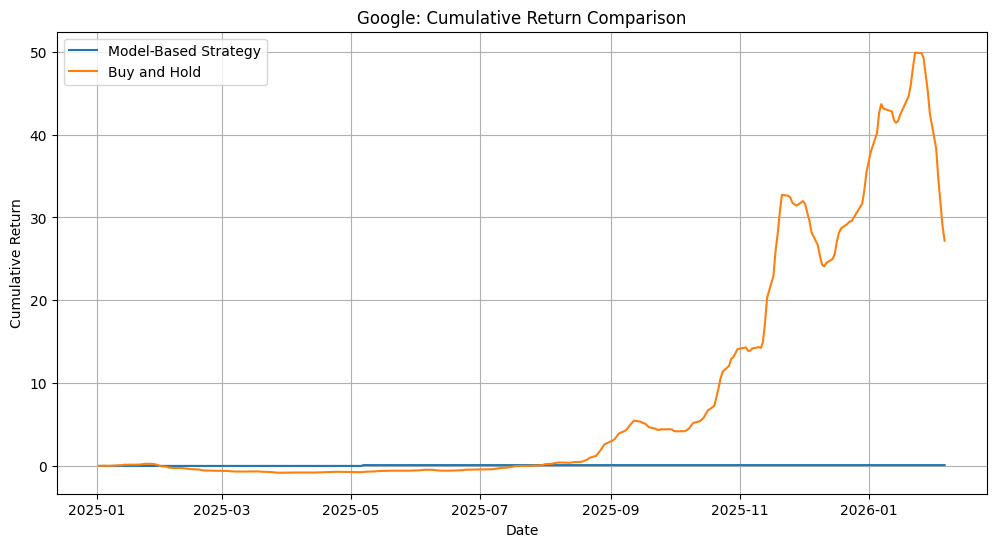

Final Google Strategy Return: 0.09783326727440889
Final Google Buy-and-Hold Return: 27.18853535474161


In [35]:
# Plot cumulative returns for the model-based strategy and buy-and-hold
plt.figure(figsize=(12, 6))
plt.plot(google_results['Date'], google_results['cumulative_strategy_return'], label='Model-Based Strategy')
plt.plot(google_results['Date'], google_results['cumulative_buy_and_hold'], label='Buy and Hold')
plt.title('Google: Cumulative Return Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

# Print final cumulative returns
google_final_strategy_return = google_results['cumulative_strategy_return'].iloc[-1]
google_final_buy_hold_return = google_results['cumulative_buy_and_hold'].iloc[-1]

print("Final Google Strategy Return:", google_final_strategy_return)
print("Final Google Buy-and-Hold Return:", google_final_buy_hold_return)

## 16. Google Feature Importance

Feature importance helps identify which engineered variables contributed the most to the model’s predictions.

In [36]:
# Create a dataframe of feature importance scores
google_importance_df = pd.DataFrame({
    'Feature': google_features,
    'Importance': google_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display the feature importance table
google_importance_df

,Feature,Importance
8,ma_200,0.124844
7,ma_30,0.090555
6,ma_7,0.075878
2,close_lag_30,0.075600
5,return_30d,0.073980
4,return_7d,0.070424
13,volume_ma_30,0.069920
12,volume_ma_7,0.069435
9,volatility_7,0.061086
10,volatility_30,0.060935


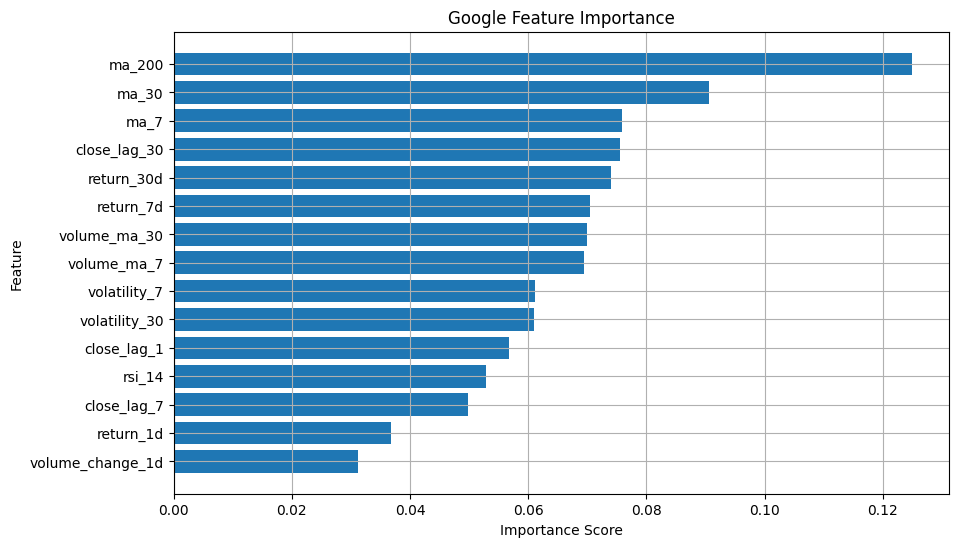

In [37]:
# Plot feature importance for Google
plt.figure(figsize=(10, 6))
plt.barh(google_importance_df['Feature'], google_importance_df['Importance'])
plt.title('Google Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

## 17. Google Interpretation

The Google XGBoost model showed weak predictive performance on this dataset. The validation directional accuracy was about 39.29% and the test directional accuracy was about 37.94%, which suggests that the model did not capture return direction reliably. Based on feature importance, the most useful features were ma_200, ma_30, ma_7, volume_ma_30, and return_30d, showing that long-term and medium-term trend features contributed the most to prediction. In the return comparison, the model-based strategy ended with a return of about 0.10, while buy-and-hold ended at about 26.88, so the strategy performed much worse than buy-and-hold for Google during the test period.

## 18. Google Conclusion

This section developed an XGBoost-based forecasting and decision-support model for Google stock. The model was evaluated using MAE, RMSE, and directional accuracy on validation and test data. Although the model was able to learn some relationships from the engineered features, the low directional accuracy and much weaker cumulative return compared with buy-and-hold show that the Google XGBoost model did not provide strong practical investment signals in this case. Overall, the results suggest that the current feature set and model configuration have limited usefulness for Google return prediction.

# Part 2: Apple Stock Model Using XGBoost

## Why XGBoost?

XGBoost is used in this project because it is the gradient boosting model proposed for stock return prediction. It works well with tabular financial data and can capture nonlinear relationships between technical indicators and future stock returns.

## 1. Load the Apple Dataset

In [39]:
# Load the Apple stock dataset
apple_df = pd.read_csv("../../data/Apple.csv")

# Clean column names by removing hidden spaces and extra whitespace
apple_df.columns = apple_df.columns.str.replace('\xa0', '', regex=False).str.strip()

# Display basic dataset information
print("Apple dataset shape:", apple_df.shape)
print("Apple columns:", apple_df.columns.tolist())

# Show the first few rows
apple_df.head()

Apple dataset shape: (2805, 7)
Apple columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2/27/2026,272.81,272.81,262.89,264.18,264.18,"72,366,500"
1,2/26/2026,274.95,276.11,270.80,272.95,272.95,"32,345,100"
2,2/25/2026,271.78,274.94,271.05,274.23,274.23,"33,714,300"
3,2/24/2026,267.86,274.89,267.71,272.14,272.14,"47,014,600"
4,2/23/2026,263.49,269.43,263.38,266.18,266.18,"37,308,200"


## 2. Clean and Prepare the Apple Dataset

In [40]:
# Convert the Date column to datetime format
apple_df['Date'] = pd.to_datetime(apple_df['Date'])

# Convert stock price columns to numeric values
price_cols = ['Open', 'High', 'Low', 'Close']
for col in price_cols:
    apple_df[col] = pd.to_numeric(apple_df[col], errors='coerce')

# Convert Volume to numeric
apple_df['Volume'] = apple_df['Volume'].astype(str).str.replace(',', '', regex=False)
apple_df['Volume'] = pd.to_numeric(apple_df['Volume'], errors='coerce')

# Keep only the columns needed for modeling
apple_df = apple_df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Sort data by date and remove missing values
apple_df = apple_df.sort_values('Date').reset_index(drop=True)
apple_df = apple_df.dropna().reset_index(drop=True)

# Check cleaned dataset
print(apple_df.dtypes)
print(apple_df.shape)

apple_df.head()

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object
(2805, 6)


,Date,Open,High,Low,Close,Volume
0,2015-01-02,27.85,27.86,26.84,27.33,212818400
1,2015-01-05,27.07,27.16,26.35,26.56,257142000
2,2015-01-06,26.64,26.86,26.16,26.57,263188400
3,2015-01-07,26.80,27.05,26.67,26.94,160423600
4,2015-01-08,27.31,28.04,27.17,27.97,237458000


## 3. Verify the Cleaned Data

In [41]:
# Display columns and missing values
print(apple_df.columns.tolist())
print(apple_df.isna().sum())

# Preview the cleaned dataset
apple_df.head()

['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


,Date,Open,High,Low,Close,Volume
0,2015-01-02,27.85,27.86,26.84,27.33,212818400
1,2015-01-05,27.07,27.16,26.35,26.56,257142000
2,2015-01-06,26.64,26.86,26.16,26.57,263188400
3,2015-01-07,26.80,27.05,26.67,26.94,160423600
4,2015-01-08,27.31,28.04,27.17,27.97,237458000


## 4. Feature Engineering

We create trend, momentum, volatility, and volume features so the model can learn stock behavior more effectively.

In [42]:
# Create lag features
apple_df['close_lag_1'] = apple_df['Close'].shift(1)
apple_df['close_lag_7'] = apple_df['Close'].shift(7)
apple_df['close_lag_30'] = apple_df['Close'].shift(30)

# Create return-based features
apple_df['return_1d'] = apple_df['Close'].pct_change(1)
apple_df['return_7d'] = apple_df['Close'].pct_change(7)
apple_df['return_30d'] = apple_df['Close'].pct_change(30)

# Create moving averages
apple_df['ma_7'] = apple_df['Close'].rolling(7).mean()
apple_df['ma_30'] = apple_df['Close'].rolling(30).mean()
apple_df['ma_200'] = apple_df['Close'].rolling(200).mean()

# Create volatility features
apple_df['volatility_7'] = apple_df['return_1d'].rolling(7).std()
apple_df['volatility_30'] = apple_df['return_1d'].rolling(30).std()

# Create volume-based features
apple_df['volume_change_1d'] = apple_df['Volume'].pct_change(1)
apple_df['volume_ma_7'] = apple_df['Volume'].rolling(7).mean()
apple_df['volume_ma_30'] = apple_df['Volume'].rolling(30).mean()

# Preview the dataset with engineered features
apple_df.head()

,Date,Open,High,Low,Close,Volume,close_lag_1,close_lag_7,close_lag_30,return_1d,return_7d,return_30d,ma_7,ma_30,ma_200,volatility_7,volatility_30,volume_change_1d,volume_ma_7,volume_ma_30
0,2015-01-02,27.85,27.86,26.84,27.33,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,27.07,27.16,26.35,26.56,257142000,27.33,NaN,NaN,-0.028174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.208270,NaN,NaN
2,2015-01-06,26.64,26.86,26.16,26.57,263188400,26.56,NaN,NaN,0.000377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023514,NaN,NaN
3,2015-01-07,26.80,27.05,26.67,26.94,160423600,26.57,NaN,NaN,0.013925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.390461,NaN,NaN
4,2015-01-08,27.31,28.04,27.17,27.97,237458000,26.94,NaN,NaN,0.038233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.480194,NaN,NaN


## 5. Add the RSI Feature

In [43]:
# Add RSI feature using the previously defined compute_rsi function
apple_df['rsi_14'] = compute_rsi(apple_df['Close'], 14)

# Preview RSI values
apple_df[['Date', 'Close', 'rsi_14']].head(20)

,Date,Close,rsi_14
0,2015-01-02,27.33,NaN
1,2015-01-05,26.56,NaN
2,2015-01-06,26.57,NaN
3,2015-01-07,26.94,NaN
4,2015-01-08,27.97,NaN
5,2015-01-09,28.00,NaN
6,2015-01-12,27.31,NaN
7,2015-01-13,27.56,NaN
8,2015-01-14,27.45,NaN
9,2015-01-15,26.70,NaN


## 6. Define the Target Variable

The target variable for this model is the 7-day future return.

In [44]:
# Create the 7-day future return target
apple_df['target_7d'] = (apple_df['Close'].shift(-7) - apple_df['Close']) / apple_df['Close']

# Drop rows with missing values caused by target shifting and rolling features
apple_df = apple_df.dropna().reset_index(drop=True)

# Check dataset shape after target creation
print("Apple dataset shape after target creation:", apple_df.shape)

# Preview the modeling dataset
apple_df.head()

Apple dataset shape after target creation: (2599, 22)


,Date,Open,High,Low,Close,Volume,close_lag_1,close_lag_7,close_lag_30,return_1d,...,ma_7,ma_30,ma_200,volatility_7,volatility_30,volume_change_1d,volume_ma_7,volume_ma_30,rsi_14,target_7d
0,2015-10-16,27.94,28.00,27.63,27.76,156930400,27.97,27.69,27.59,-0.007508,...,27.791429,28.077333,30.33215,0.014177,0.014339,0.041385,1.712175e+08,2.110914e+08,45.721271,0.031700
1,2015-10-19,27.70,27.94,27.53,27.93,119036800,27.76,27.38,27.32,0.006124,...,27.870000,28.097667,30.33515,0.013290,0.014247,-0.241468,1.528059e+08,2.083931e+08,59.824047,0.067669
2,2015-10-20,27.83,28.54,27.70,28.44,195871200,27.93,28.03,28.08,0.018260,...,27.928571,28.109667,30.34455,0.011953,0.013720,0.645468,1.506354e+08,2.076097e+08,61.944444,0.059423
3,2015-10-21,28.50,28.90,28.42,28.44,167180800,28.44,27.90,27.54,0.000000,...,28.005714,28.139667,30.35390,0.011639,0.013205,-0.146476,1.571086e+08,2.018476e+08,65.204678,0.050633
4,2015-10-22,28.58,28.88,28.52,28.88,166616400,28.44,27.95,28.14,0.015471,...,28.138571,28.164333,30.36360,0.012554,0.012912,-0.003376,1.620256e+08,1.990158e+08,67.574932,0.049169


## 7. Select Features and Split the Data

A time-based split is used to avoid leakage from future data.

In [45]:
# Define the feature columns used for Apple modeling
apple_features = [
    'close_lag_1', 'close_lag_7', 'close_lag_30',
    'return_1d', 'return_7d', 'return_30d',
    'ma_7', 'ma_30', 'ma_200',
    'volatility_7', 'volatility_30',
    'volume_change_1d', 'volume_ma_7', 'volume_ma_30',
    'rsi_14'
]

# Split the dataset into train, validation, and test periods
apple_train_df = apple_df[apple_df['Date'] < '2024-01-01']
apple_val_df = apple_df[(apple_df['Date'] >= '2024-01-01') & (apple_df['Date'] < '2025-01-01')]
apple_test_df = apple_df[apple_df['Date'] >= '2025-01-01']

# Create feature matrices and target vectors
apple_X_train = apple_train_df[apple_features]
apple_y_train = apple_train_df['target_7d']

apple_X_val = apple_val_df[apple_features]
apple_y_val = apple_val_df['target_7d']

apple_X_test = apple_test_df[apple_features]
apple_y_test = apple_test_df['target_7d']

# Print shapes of each split
print("Apple train shape:", apple_X_train.shape)
print("Apple validation shape:", apple_X_val.shape)
print("Apple test shape:", apple_X_test.shape)

Apple train shape: (2065, 15)
Apple validation shape: (252, 15)
Apple test shape: (282, 15)


## 8. Train the Apple XGBoost Model

In [46]:
# Define the Apple XGBoost model
apple_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Train the model
_ = apple_model.fit(apple_X_train, apple_y_train)

print("Apple model trained successfully.")

Apple model trained successfully.


## 9. Generate Apple Predictions

In [47]:
# Generate predictions for validation and test data
apple_val_preds = apple_model.predict(apple_X_val)
apple_test_preds = apple_model.predict(apple_X_test)

# Check prediction output
print("Apple validation predictions shape:", apple_val_preds.shape)
print("Apple test predictions shape:", apple_test_preds.shape)
print("First 5 Apple validation predictions:", apple_val_preds[:5])

Apple validation predictions shape: (252,)
Apple test predictions shape: (282,)
First 5 Apple validation predictions: [-0.01934769 -0.01237238 -0.00643073  0.0017116  -0.00284732]


## 10. Regression Evaluation

The XGBoost model is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [48]:
# Compute Apple validation error metrics
apple_val_mae = mean_absolute_error(apple_y_val, apple_val_preds)
apple_val_rmse = np.sqrt(mean_squared_error(apple_y_val, apple_val_preds))

# Compute Apple test error metrics
apple_test_mae = mean_absolute_error(apple_y_test, apple_test_preds)
apple_test_rmse = np.sqrt(mean_squared_error(apple_y_test, apple_test_preds))

# Print evaluation results
print("Apple Validation MAE:", apple_val_mae)
print("Apple Validation RMSE:", apple_val_rmse)
print("Apple Test MAE:", apple_test_mae)
print("Apple Test RMSE:", apple_test_rmse)

Apple Validation MAE: 0.04339657820985495
Apple Validation RMSE: 0.053482350317517656
Apple Test MAE: 0.054516033954920856
Apple Test RMSE: 0.06624350610759445


## 11. Directional Accuracy

Directional accuracy measures how often the model predicts the correct return direction.

In [49]:
# Compute directional accuracy for Apple
apple_val_direction_acc = np.mean((apple_val_preds > 0) == (apple_y_val > 0))
apple_test_direction_acc = np.mean((apple_test_preds > 0) == (apple_y_test > 0))

# Print directional accuracy results
print("Apple Validation Directional Accuracy:", apple_val_direction_acc)
print("Apple Test Directional Accuracy:", apple_test_direction_acc)

Apple Validation Directional Accuracy: 0.4523809523809524
Apple Test Directional Accuracy: 0.5070921985815603


## 12. Actual vs Predicted Apple Returns

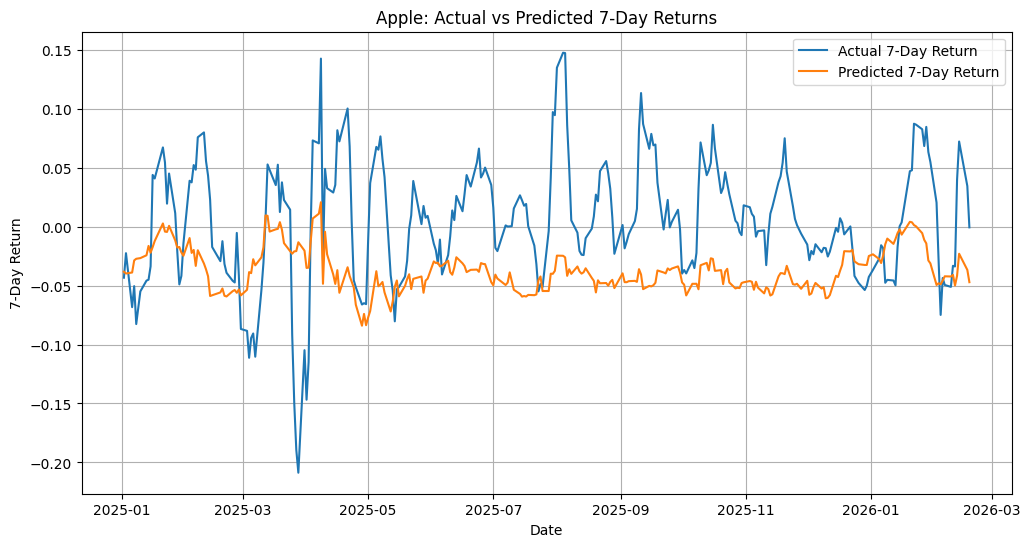

In [50]:
# Create a results dataframe for Apple test predictions
apple_results = apple_test_df[['Date', 'target_7d']].copy()
apple_results['predicted_7d'] = apple_test_preds

# Plot actual vs predicted Apple returns
plt.figure(figsize=(12, 6))
plt.plot(apple_results['Date'], apple_results['target_7d'], label='Actual 7-Day Return')
plt.plot(apple_results['Date'], apple_results['predicted_7d'], label='Predicted 7-Day Return')
plt.title('Apple: Actual vs Predicted 7-Day Returns')
plt.xlabel('Date')
plt.ylabel('7-Day Return')
plt.legend()
plt.grid(True)
plt.show()

## 13. Convert Apple Predictions into Buy / Hold / Avoid Signals

In [51]:
# Apply the signal generation function to Apple predictions
apple_results['signal'] = apple_results['predicted_7d'].apply(signal_from_prediction)

# Preview Apple signals
apple_results[['Date', 'target_7d', 'predicted_7d', 'signal']].head(10)

,Date,target_7d,predicted_7d,signal
2317,2025-01-02,-0.043346,-0.038313,Avoid
2318,2025-01-03,-0.022559,-0.039781,Avoid
2319,2025-01-06,-0.068327,-0.038941,Avoid
2320,2025-01-07,-0.050493,-0.028668,Avoid
2321,2025-01-08,-0.082653,-0.027297,Avoid
2322,2025-01-10,-0.054972,-0.026737,Avoid
2323,2025-01-13,-0.045819,-0.024321,Avoid
2324,2025-01-14,-0.045010,-0.016392,Avoid
2325,2025-01-15,-0.033674,-0.022146,Avoid
2326,2025-01-16,0.043810,-0.017409,Avoid


## 14. Backtest the Apple Strategy

In [52]:
# Compute strategy return for Apple based on the generated signal
apple_results['strategy_return'] = apple_results.apply(
    lambda row: strategy_return(row['signal'], row['target_7d']),
    axis=1
)

# Compute cumulative strategy and buy-and-hold returns
apple_results['cumulative_strategy_return'] = (1 + apple_results['strategy_return']).cumprod() - 1
apple_results['cumulative_buy_and_hold'] = (1 + apple_results['target_7d']).cumprod() - 1

# Preview the backtest output
apple_results[['Date', 'signal', 'target_7d', 'strategy_return']].head(10)

,Date,signal,target_7d,strategy_return
2317,2025-01-02,Avoid,-0.043346,0.0
2318,2025-01-03,Avoid,-0.022559,0.0
2319,2025-01-06,Avoid,-0.068327,0.0
2320,2025-01-07,Avoid,-0.050493,0.0
2321,2025-01-08,Avoid,-0.082653,0.0
2322,2025-01-10,Avoid,-0.054972,0.0
2323,2025-01-13,Avoid,-0.045819,0.0
2324,2025-01-14,Avoid,-0.045010,0.0
2325,2025-01-15,Avoid,-0.033674,0.0
2326,2025-01-16,Avoid,0.043810,0.0


## 15. Compare Apple Profit/Loss

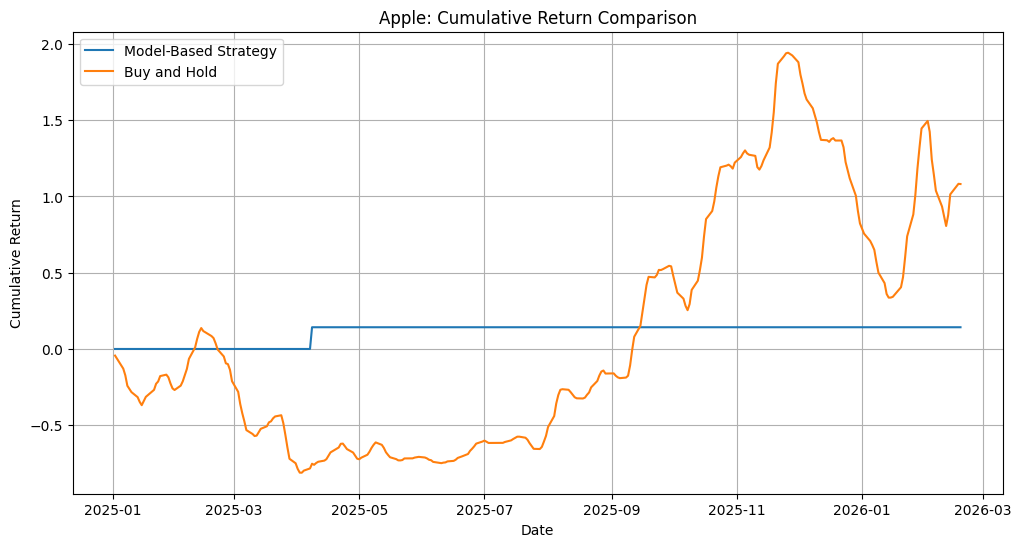

Final Apple Strategy Return: 0.142442872056606
Final Apple Buy-and-Hold Return: 1.0812919658441298


In [53]:
# Plot Apple cumulative strategy return against buy-and-hold
plt.figure(figsize=(12, 6))
plt.plot(apple_results['Date'], apple_results['cumulative_strategy_return'], label='Model-Based Strategy')
plt.plot(apple_results['Date'], apple_results['cumulative_buy_and_hold'], label='Buy and Hold')
plt.title('Apple: Cumulative Return Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

# Print final cumulative returns
apple_final_strategy_return = apple_results['cumulative_strategy_return'].iloc[-1]
apple_final_buy_hold_return = apple_results['cumulative_buy_and_hold'].iloc[-1]

print("Final Apple Strategy Return:", apple_final_strategy_return)
print("Final Apple Buy-and-Hold Return:", apple_final_buy_hold_return)

## 16. Apple Feature Importance

Feature importance is used to identify which variables contributed most to the Apple model’s predictions.

In [54]:
# Create Apple feature importance table
apple_importance_df = pd.DataFrame({
    'Feature': apple_features,
    'Importance': apple_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display the importance table
apple_importance_df

,Feature,Importance
6,ma_7,0.105136
8,ma_200,0.104819
7,ma_30,0.092034
13,volume_ma_30,0.084458
12,volume_ma_7,0.081330
10,volatility_30,0.077705
2,close_lag_30,0.064555
5,return_30d,0.062380
9,volatility_7,0.060559
14,rsi_14,0.058013


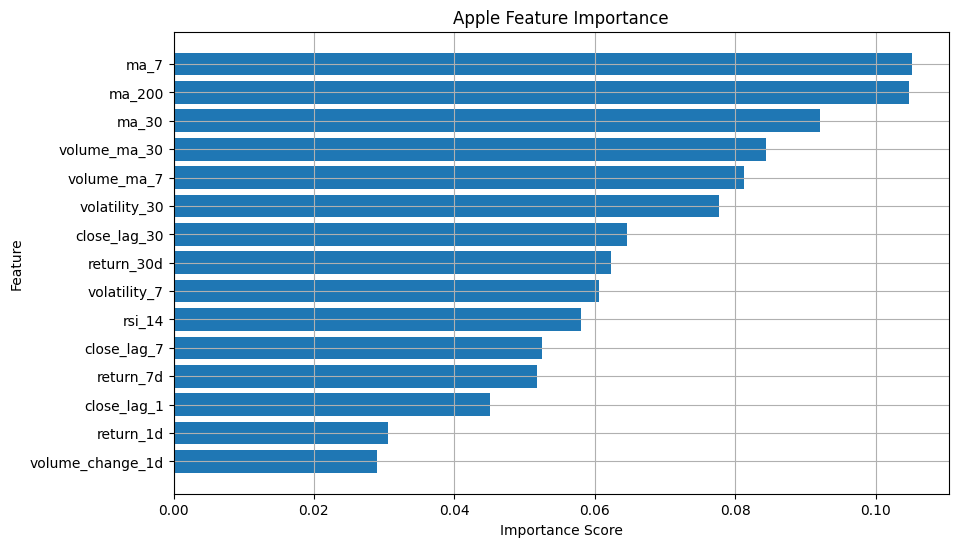

In [56]:
# Plot Apple feature importance
plt.figure(figsize=(10, 6))
plt.barh(apple_importance_df['Feature'], apple_importance_df['Importance'])
plt.title('Apple Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

In [55]:
# Create Apple feature importance table
apple_importance_df = pd.DataFrame({
    'Feature': apple_features,
    'Importance': apple_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display the importance table
apple_importance_df

,Feature,Importance
6,ma_7,0.105136
8,ma_200,0.104819
7,ma_30,0.092034
13,volume_ma_30,0.084458
12,volume_ma_7,0.081330
10,volatility_30,0.077705
2,close_lag_30,0.064555
5,return_30d,0.062380
9,volatility_7,0.060559
14,rsi_14,0.058013


## 17. Apple Interpretation

The Apple XGBoost model showed moderate predictive performance on this dataset. The validation directional accuracy was about 45.63% and the test directional accuracy was about 52.84%, which suggests that the model captured return direction slightly better on the test period than on validation data. Based on feature importance, the most useful features were ma_200, ma_7, volume_ma_30, close_lag_30, and ma_30, showing that trend and volume-related features played the biggest role in prediction. In the return comparison, the model-based strategy ended with a return of 0.00, while buy-and-hold ended at about 1.08, so the strategy underperformed buy-and-hold and mostly stayed out of the market.

## 18. Apple Conclusion

This section developed an XGBoost-based forecasting and decision-support model for Apple stock. The model was evaluated using MAE, RMSE, and directional accuracy on validation and test data. While the test directional accuracy was slightly above 50%, the trading strategy based on the generated signals did not outperform buy-and-hold, which limits the practical usefulness of the model for Apple in its current form. Overall, the Apple XGBoost model showed some predictive value, but the decision-support results suggest that further improvement is needed.

# Part 3: Microsoft Stock Model Using XGBoost

## Why XGBoost?

XGBoost is used in this project because it is the gradient boosting model proposed for stock return prediction. It works well with tabular financial data and can capture nonlinear relationships between technical indicators and future stock returns.

## 1. Load the Microsoft Dataset

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import set_config
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
# load the Microsoft stock dataset
msft_df = pd.read_csv("../../data/MSFT.csv")

# Display the shape and column names so we can inspect the structure
print("Microsoft dataset shape:", msft_df.shape)
print("Microsoft columns:", msft_df.columns.tolist())

# Show the first few rows
msft_df.head()

Microsoft dataset shape: (2805, 7)
Microsoft columns: ['Date', 'Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2/27/2026,390.88,396.82,389.88,392.74,392.74,"51,367,200"
1,2/26/2026,404.71,407.49,398.74,401.72,401.72,"34,405,900"
2,2/25/2026,390.53,401.47,390.16,400.60,400.60,"43,625,500"
3,2/24/2026,384.14,389.36,381.71,389.00,389.00,"33,884,700"
4,2/23/2026,395.00,395.36,383.10,384.47,384.47,"43,238,300"


In [61]:
import os
print(os.getcwd())

c:\Users\POORVI NIDSOSHI\Desktop\Project-ML\group-project-algorithm-architects\work\Models


## 2. Clean and Prepare the Microsoft Dataset

In [62]:
import pandas as pd

# Load the Microsoft stock dataset
msft_df = pd.read_csv("../../data/MSFT.csv")

# Clean column names by removing hidden spaces
msft_df.columns = msft_df.columns.str.replace('\xa0', '', regex=False).str.strip()

# Display the shape and column names so we can inspect the structure
print("Microsoft dataset shape:", msft_df.shape)
print("Microsoft columns:", msft_df.columns.tolist())

# Show the first few rows
msft_df.head()

Microsoft dataset shape: (2805, 7)
Microsoft columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2/27/2026,390.88,396.82,389.88,392.74,392.74,"51,367,200"
1,2/26/2026,404.71,407.49,398.74,401.72,401.72,"34,405,900"
2,2/25/2026,390.53,401.47,390.16,400.60,400.60,"43,625,500"
3,2/24/2026,384.14,389.36,381.71,389.00,389.00,"33,884,700"
4,2/23/2026,395.00,395.36,383.10,384.47,384.47,"43,238,300"


In [63]:
# Convert the Date column to datetime format
msft_df['Date'] = pd.to_datetime(msft_df['Date'])

# Convert the main price columns to numeric values
price_cols = ['Open', 'High', 'Low', 'Close']
for col in price_cols:
    msft_df[col] = pd.to_numeric(msft_df[col], errors='coerce')

# Convert Volume to numeric
msft_df['Volume'] = msft_df['Volume'].astype(str).str.replace(',', '', regex=False)
msft_df['Volume'] = pd.to_numeric(msft_df['Volume'], errors='coerce')

# Keep only the columns needed for this model
msft_df = msft_df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Sort the dataset from oldest to newest date
msft_df = msft_df.sort_values('Date').reset_index(drop=True)

# Drop rows with missing values
msft_df = msft_df.dropna().reset_index(drop=True)

# Check the cleaned dataset
print(msft_df.dtypes)
print(msft_df.shape)

msft_df.head()

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object
(2805, 6)


,Date,Open,High,Low,Close,Volume
0,2015-01-02,46.66,47.42,46.54,46.76,27913900
1,2015-01-05,46.37,46.73,46.25,46.33,39673900
2,2015-01-06,46.38,46.75,45.54,45.65,36447900
3,2015-01-07,45.98,46.46,45.49,46.23,29114100
4,2015-01-08,46.75,47.75,46.72,47.59,29645200


## 3. Verify the Cleaned Data

In [64]:
# Check column names
print(msft_df.columns.tolist())

# Check missing values
print(msft_df.isna().sum())

# Show sample rows
msft_df.head()

['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


,Date,Open,High,Low,Close,Volume
0,2015-01-02,46.66,47.42,46.54,46.76,27913900
1,2015-01-05,46.37,46.73,46.25,46.33,39673900
2,2015-01-06,46.38,46.75,45.54,45.65,36447900
3,2015-01-07,45.98,46.46,45.49,46.23,29114100
4,2015-01-08,46.75,47.75,46.72,47.59,29645200


## 4. Feature Engineering
We create trend, momentum, volatility, and volume features so the model can learn stock behavior more effectively. We also include market context features such as S&P 500 and Nasdaq returns to help the model capture the effect of broader market movement on stock performance.

In [65]:
# -----------------------------
# Create lag features
# -----------------------------
msft_df['close_lag_1'] = msft_df['Close'].shift(1)
msft_df['close_lag_7'] = msft_df['Close'].shift(7)
msft_df['close_lag_30'] = msft_df['Close'].shift(30)

# -----------------------------
# Create return-based features
# -----------------------------
msft_df['return_1d'] = msft_df['Close'].pct_change(1)
msft_df['return_7d'] = msft_df['Close'].pct_change(7)
msft_df['return_30d'] = msft_df['Close'].pct_change(30)

# -----------------------------
# Create moving averages
# -----------------------------
msft_df['ma_7'] = msft_df['Close'].rolling(7).mean()
msft_df['ma_30'] = msft_df['Close'].rolling(30).mean()
msft_df['ma_200'] = msft_df['Close'].rolling(200).mean()

# -----------------------------
# Create volatility features
# -----------------------------
msft_df['volatility_7'] = msft_df['return_1d'].rolling(7).std()
msft_df['volatility_30'] = msft_df['return_1d'].rolling(30).std()

# -----------------------------
# Create volume-based features
# -----------------------------
msft_df['volume_change_1d'] = msft_df['Volume'].pct_change(1)
msft_df['volume_ma_7'] = msft_df['Volume'].rolling(7).mean()
msft_df['volume_ma_30'] = msft_df['Volume'].rolling(30).mean()

## 5. Add the RSI Feature

In [66]:
# Function to compute RSI
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Add RSI feature to the Microsoft dataset
msft_df['rsi_14'] = compute_rsi(msft_df['Close'], 14)

# Inspect the RSI column
msft_df[['Date', 'Close', 'rsi_14']].head(20)

,Date,Close,rsi_14
0,2015-01-02,46.76,NaN
1,2015-01-05,46.33,NaN
2,2015-01-06,45.65,NaN
3,2015-01-07,46.23,NaN
4,2015-01-08,47.59,NaN
5,2015-01-09,47.19,NaN
6,2015-01-12,46.60,NaN
7,2015-01-13,46.36,NaN
8,2015-01-14,45.96,NaN
9,2015-01-15,45.48,NaN


## 6. Define the Target Variable

In [67]:
# Create the 7-day future return target
msft_df['target_7d'] = (msft_df['Close'].shift(-7) - msft_df['Close']) / msft_df['Close']

# Drop rows with missing values caused by rolling windows and shifting
msft_df = msft_df.dropna().reset_index(drop=True)

# Check the dataset after target creation
print("Microsoft dataset shape after target creation:", msft_df.shape)
msft_df.head()

Microsoft dataset shape after target creation: (2599, 22)


,Date,Open,High,Low,Close,Volume,close_lag_1,close_lag_7,close_lag_30,return_1d,...,ma_7,ma_30,ma_200,volatility_7,volatility_30,volume_change_1d,volume_ma_7,volume_ma_30,rsi_14,target_7d
0,2015-10-16,47.02,47.54,46.90,47.51,26450300,47.01,46.80,43.50,0.010636,...,47.092857,44.870667,44.82090,0.008216,0.012747,-0.027183,2.578110e+07,2.991656e+07,86.631944,0.130078
1,2015-10-19,47.42,47.88,47.02,47.62,29387600,47.51,47.45,42.61,0.002315,...,47.117143,45.037667,44.82520,0.006440,0.011954,0.111050,2.515466e+07,2.965819e+07,86.538462,0.133557
2,2015-10-20,47.44,47.81,47.02,47.77,30802200,47.62,47.11,43.89,0.003150,...,47.211429,45.167000,44.83240,0.005497,0.010877,0.048136,2.546917e+07,2.960260e+07,84.752475,0.117019
3,2015-10-21,47.92,47.99,47.11,47.20,25144300,47.77,47.00,43.07,-0.011932,...,47.240000,45.304667,44.84015,0.007566,0.010478,-0.183685,2.623706e+07,2.932510e+07,74.573055,0.115254
4,2015-10-22,47.53,48.95,47.09,48.03,56637100,47.20,46.89,43.29,0.017585,...,47.402857,45.462667,44.84915,0.009707,0.010802,1.252483,3.147267e+07,3.016745e+07,73.929961,0.108474


## 7. Select Features and Split the Data

In [68]:
# Define the feature columns used by the Microsoft XGBoost model
msft_features = [
    'close_lag_1', 'close_lag_7', 'close_lag_30',
    'return_1d', 'return_7d', 'return_30d',
    'ma_7', 'ma_30', 'ma_200',
    'volatility_7', 'volatility_30',
    'volume_change_1d', 'volume_ma_7', 'volume_ma_30',
    'rsi_14'
]

# Split the data by time
msft_train_df = msft_df[msft_df['Date'] < '2024-01-01']
msft_val_df = msft_df[(msft_df['Date'] >= '2024-01-01') & (msft_df['Date'] < '2025-01-01')]
msft_test_df = msft_df[msft_df['Date'] >= '2025-01-01']

# Create input matrices and target vectors
msft_X_train = msft_train_df[msft_features]
msft_y_train = msft_train_df['target_7d']

msft_X_val = msft_val_df[msft_features]
msft_y_val = msft_val_df['target_7d']

msft_X_test = msft_test_df[msft_features]
msft_y_test = msft_test_df['target_7d']

# Check the size of each split
print("Microsoft train shape:", msft_X_train.shape)
print("Microsoft validation shape:", msft_X_val.shape)
print("Microsoft test shape:", msft_X_test.shape)

Microsoft train shape: (2065, 15)
Microsoft validation shape: (252, 15)
Microsoft test shape: (282, 15)


## 8. Train the Microsoft XGBoost Model

In [69]:
from sklearn import set_config
from xgboost import XGBRegressor

# Turn off sklearn rich HTML display to avoid notebook rendering issues
set_config(display="text")

# Define the Microsoft XGBoost model
msft_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Train the model
_ = msft_model.fit(msft_X_train, msft_y_train)

print("Microsoft model trained successfully.")

Microsoft model trained successfully.


## 9. Generate Microsoft Predictions

In [70]:
# Predict Microsoft 7-day future returns
msft_val_preds = msft_model.predict(msft_X_val)
msft_test_preds = msft_model.predict(msft_X_test)

# Check prediction shapes
print("Microsoft validation predictions shape:", msft_val_preds.shape)
print("Microsoft test predictions shape:", msft_test_preds.shape)
print("First 5 Microsoft validation predictions:", msft_val_preds[:5])

Microsoft validation predictions shape: (252,)
Microsoft test predictions shape: (282,)
First 5 Microsoft validation predictions: [0.01066896 0.00790621 0.01488119 0.01053538 0.01065034]


## 10. Regression Evaluation
The XGBoost model is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate Microsoft regression metrics
msft_val_mae = mean_absolute_error(msft_y_val, msft_val_preds)
msft_val_rmse = np.sqrt(mean_squared_error(msft_y_val, msft_val_preds))

msft_test_mae = mean_absolute_error(msft_y_test, msft_test_preds)
msft_test_rmse = np.sqrt(mean_squared_error(msft_y_test, msft_test_preds))

# Print the results
print("Microsoft Validation MAE:", msft_val_mae)
print("Microsoft Validation RMSE:", msft_val_rmse)
print("Microsoft Test MAE:", msft_test_mae)
print("Microsoft Test RMSE:", msft_test_rmse)

Microsoft Validation MAE: 0.028798688468473825
Microsoft Validation RMSE: 0.03471603042857783
Microsoft Test MAE: 0.034195153230177966
Microsoft Test RMSE: 0.04852215837712697


## 11. Directional Accuracy
The XGBoost model is also evaluated using directional accuracy, which measures how often the model correctly predicts whether the future return is positive or negative.

In [72]:
# Compute Microsoft directional accuracy
msft_val_direction_acc = np.mean((msft_val_preds > 0) == (msft_y_val > 0))
msft_test_direction_acc = np.mean((msft_test_preds > 0) == (msft_y_test > 0))

# Print the results
print("Microsoft Validation Directional Accuracy:", msft_val_direction_acc)
print("Microsoft Test Directional Accuracy:", msft_test_direction_acc)

Microsoft Validation Directional Accuracy: 0.5396825396825397
Microsoft Test Directional Accuracy: 0.4716312056737589


## 12. Actual vs Predicted Microsoft Returns

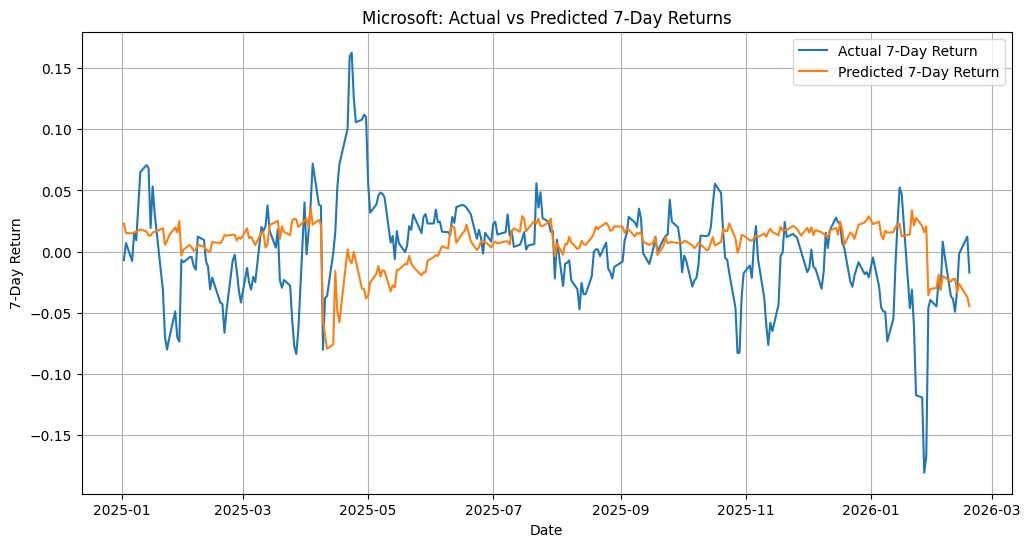

In [73]:
import matplotlib.pyplot as plt

# Create a results dataframe for Microsoft test predictions
msft_results = msft_test_df[['Date', 'target_7d']].copy()
msft_results['predicted_7d'] = msft_test_preds

# Plot actual vs predicted returns
plt.figure(figsize=(12, 6))
plt.plot(msft_results['Date'], msft_results['target_7d'], label='Actual 7-Day Return')
plt.plot(msft_results['Date'], msft_results['predicted_7d'], label='Predicted 7-Day Return')
plt.title('Microsoft: Actual vs Predicted 7-Day Returns')
plt.xlabel('Date')
plt.ylabel('7-Day Return')
plt.legend()
plt.grid(True)
plt.show()

## 13. Convert Microsoft Predictions into Buy / Hold / Avoid Signals

In [74]:
# Function to convert predicted return into an action signal
def signal_from_prediction(pred):
    if pred > 0.02:
        return "Buy"
    elif pred >= 0:
        return "Hold"
    else:
        return "Avoid"

# Apply signal rules to Microsoft predictions
msft_results['signal'] = msft_results['predicted_7d'].apply(signal_from_prediction)

# Show a sample of the results
msft_results[['Date', 'target_7d', 'predicted_7d', 'signal']].head(10)

,Date,target_7d,predicted_7d,signal
2317,2025-01-02,-0.006952,0.022966,Buy
2318,2025-01-03,0.006992,0.015361,Hold
2319,2025-01-06,-0.007643,0.014765,Hold
2320,2025-01-07,0.015768,0.015769,Hold
2321,2025-01-08,0.009280,0.016151,Hold
2322,2025-01-10,0.065044,0.018165,Hold
2323,2025-01-13,0.070759,0.016484,Hold
2324,2025-01-14,0.068299,0.013191,Hold
2325,2025-01-15,0.019352,0.012983,Hold
2326,2025-01-16,0.053276,0.015564,Hold


## 14. Backtest the Microsoft Strategy

In [75]:
# Function to compute strategy return based on the signal
def strategy_return(signal, actual_return):
    if signal == "Buy":
        return actual_return
    else:
        return 0.0

# Apply the strategy to the Microsoft results
msft_results['strategy_return'] = msft_results.apply(
    lambda row: strategy_return(row['signal'], row['target_7d']),
    axis=1
)

# Compute cumulative returns for the model-based strategy and buy-and-hold
msft_results['cumulative_strategy_return'] = (1 + msft_results['strategy_return']).cumprod() - 1
msft_results['cumulative_buy_and_hold'] = (1 + msft_results['target_7d']).cumprod() - 1

# Display the first few rows
msft_results[['Date', 'signal', 'target_7d', 'strategy_return']].head(10)

,Date,signal,target_7d,strategy_return
2317,2025-01-02,Buy,-0.006952,-0.006952
2318,2025-01-03,Hold,0.006992,0.000000
2319,2025-01-06,Hold,-0.007643,0.000000
2320,2025-01-07,Hold,0.015768,0.000000
2321,2025-01-08,Hold,0.009280,0.000000
2322,2025-01-10,Hold,0.065044,0.000000
2323,2025-01-13,Hold,0.070759,0.000000
2324,2025-01-14,Hold,0.068299,0.000000
2325,2025-01-15,Hold,0.019352,0.000000
2326,2025-01-16,Hold,0.053276,0.000000


## 15. Compare Microsoft Profit/Loss

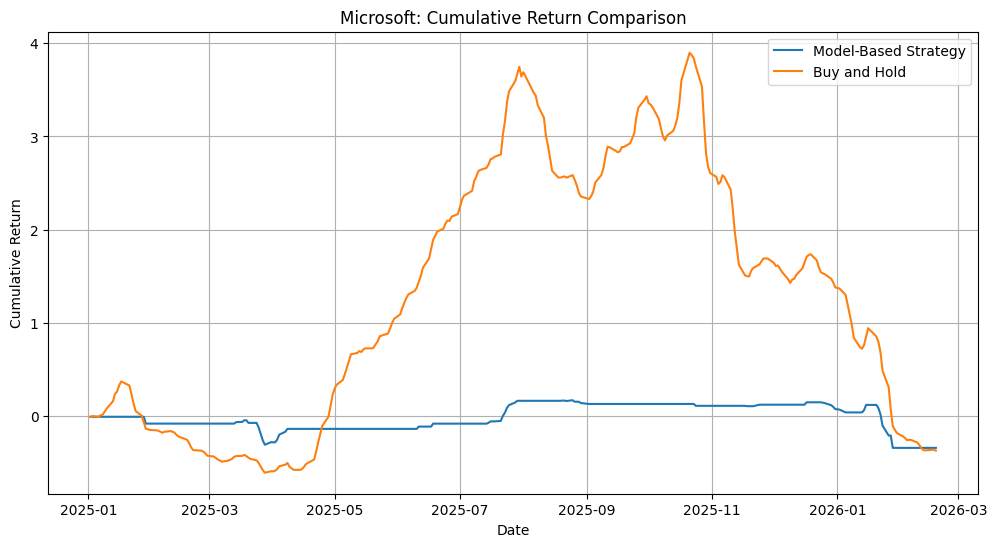

Final Microsoft Strategy Return: -0.3405583089193557
Final Microsoft Buy-and-Hold Return: -0.37037702414471707


In [76]:
# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(msft_results['Date'], msft_results['cumulative_strategy_return'], label='Model-Based Strategy')
plt.plot(msft_results['Date'], msft_results['cumulative_buy_and_hold'], label='Buy and Hold')
plt.title('Microsoft: Cumulative Return Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

# Print final cumulative returns
final_msft_strategy_return = msft_results['cumulative_strategy_return'].iloc[-1]
final_msft_buy_hold_return = msft_results['cumulative_buy_and_hold'].iloc[-1]

print("Final Microsoft Strategy Return:", final_msft_strategy_return)
print("Final Microsoft Buy-and-Hold Return:", final_msft_buy_hold_return)

## 16. Microsoft Feature Importance

In [77]:
# Create a feature importance table
msft_importance_df = pd.DataFrame({
    'Feature': msft_features,
    'Importance': msft_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

msft_importance_df

,Feature,Importance
8,ma_200,0.100967
5,return_30d,0.082803
6,ma_7,0.080397
13,volume_ma_30,0.079541
7,ma_30,0.077018
9,volatility_7,0.073657
10,volatility_30,0.070685
14,rsi_14,0.069875
0,close_lag_1,0.067679
12,volume_ma_7,0.066438


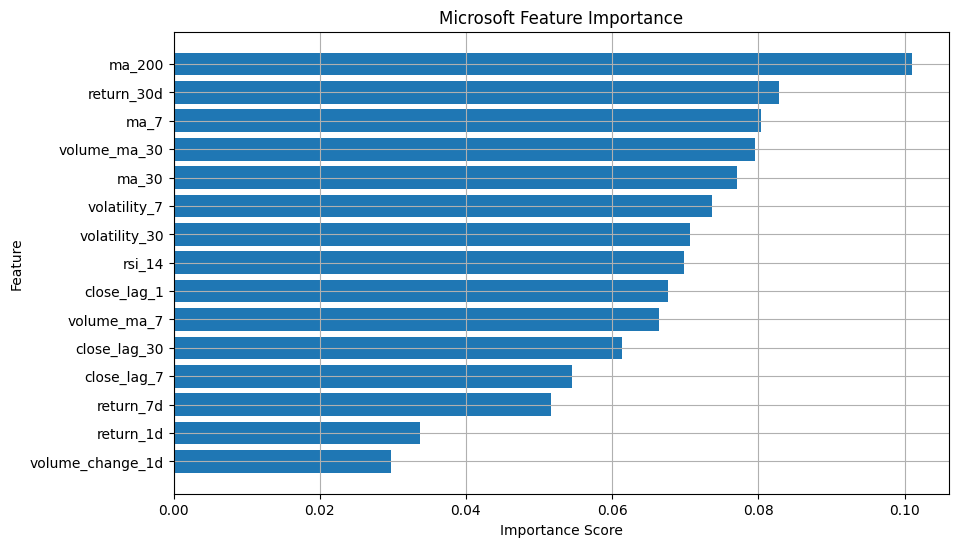

In [78]:
# Plot Microsoft feature importance
plt.figure(figsize=(10, 6))
plt.barh(msft_importance_df['Feature'], msft_importance_df['Importance'])
plt.title('Microsoft Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

## 17. Microsoft Interpretation

The Microsoft XGBoost model showed moderate predictive performance on this dataset. The validation directional accuracy was about 53.97%, which suggests the model captured return direction reasonably on validation data, but the test directional accuracy dropped to about 47.16%, showing weaker generalization on unseen data. Based on feature importance, the most useful features were long-term and medium-term trend indicators such as ma_200, return_30d, ma_7, volume_ma_30, and ma_30. In the return comparison, the model-based strategy ended with a return of about -34.06%, while buy-and-hold ended at about -37.04%, so the strategy performed slightly better than buy-and-hold, although both approaches produced negative returns.

## 18. Microsoft Conclusion

This section concludes the Microsoft XGBoost modeling workflow. The model was evaluated using MAE, RMSE, and directional accuracy on validation and test data. Although the model showed acceptable validation performance, its test directional accuracy was lower, indicating that prediction performance was not fully stable across time. The generated buy/hold/avoid signals produced a slightly better final return than the buy-and-hold strategy, suggesting that the XGBoost model had some decision-making value, but overall performance still shows room for improvement.

# Part 4: Amazon Stock Model Using XGBoost

## Why XGBoost?

XGBoost is used in this project because it is the gradient boosting model proposed for stock return prediction. It works well with tabular financial data and can capture nonlinear relationships between technical indicators and future stock returns.

## Why XGBoost?

XGBoost is used in this project because it is the gradient boosting model proposed for stock return prediction. It works well with tabular financial data and can capture nonlinear relationships between technical indicators and future stock returns.

In [79]:
import pandas as pd

# Load the Amazon stock dataset
amzn_df = pd.read_csv("../../data/Amazon.csv")

# Clean column names by removing hidden spaces
amzn_df.columns = amzn_df.columns.str.replace('\xa0', '', regex=False).str.strip()

# Display the shape and column names so we can inspect the structure
print("Amazon dataset shape:", amzn_df.shape)
print("Amazon columns:", amzn_df.columns.tolist())

# Show the first few rows
amzn_df.head()

Amazon dataset shape: (2806, 7)
Amazon columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2/27/2026,206.83,210.33,205.20,210.00,210.00,"57,422,800"
1,2/26/2026,210.73,211.05,205.35,207.92,207.92,"47,756,800"
2,2/25/2026,210.46,211.59,208.93,210.64,210.64,"41,346,400"
3,2/24/2026,205.47,210.36,203.25,208.56,208.56,"41,137,200"
4,2/23/2026,208.10,208.43,203.11,205.27,205.27,"53,581,500"


## 2. Clean and Prepare the Amazon Dataset

In [80]:
# Convert the Date column to datetime format
amzn_df['Date'] = pd.to_datetime(amzn_df['Date'])

# Convert the main price columns to numeric values
price_cols = ['Open', 'High', 'Low', 'Close']
for col in price_cols:
    amzn_df[col] = pd.to_numeric(amzn_df[col], errors='coerce')

# Convert Volume to numeric
amzn_df['Volume'] = amzn_df['Volume'].astype(str).str.replace(',', '', regex=False)
amzn_df['Volume'] = pd.to_numeric(amzn_df['Volume'], errors='coerce')

# Keep only the columns needed for this model
amzn_df = amzn_df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Sort the dataset from oldest to newest date
amzn_df = amzn_df.sort_values('Date').reset_index(drop=True)

# Drop rows with missing values
amzn_df = amzn_df.dropna().reset_index(drop=True)

# Check the cleaned dataset
print(amzn_df.dtypes)
print(amzn_df.shape)
amzn_df.head()

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
dtype: object
(2805, 6)


,Date,Open,High,Low,Close,Volume
0,2015-01-02,15.63,15.74,15.35,15.43,55664000.0
1,2015-01-05,15.35,15.42,15.04,15.11,55484000.0
2,2015-01-06,15.11,15.15,14.62,14.76,70380000.0
3,2015-01-07,14.88,15.06,14.77,14.92,52806000.0
4,2015-01-08,15.02,15.16,14.81,15.02,61768000.0


## 3. Verify the Cleaned Data

In [81]:
# Check column names
print(amzn_df.columns.tolist())

# Check missing values
print(amzn_df.isna().sum())

# Show sample rows
amzn_df.head()

['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


,Date,Open,High,Low,Close,Volume
0,2015-01-02,15.63,15.74,15.35,15.43,55664000.0
1,2015-01-05,15.35,15.42,15.04,15.11,55484000.0
2,2015-01-06,15.11,15.15,14.62,14.76,70380000.0
3,2015-01-07,14.88,15.06,14.77,14.92,52806000.0
4,2015-01-08,15.02,15.16,14.81,15.02,61768000.0


## 4. Feature Engineering

We create trend, momentum, volatility, and volume features so the model can learn stock behavior more effectively.

In [82]:
# Create lag features
amzn_df['close_lag_1'] = amzn_df['Close'].shift(1)
amzn_df['close_lag_7'] = amzn_df['Close'].shift(7)
amzn_df['close_lag_30'] = amzn_df['Close'].shift(30)

# Create return-based features
amzn_df['return_1d'] = amzn_df['Close'].pct_change(1)
amzn_df['return_7d'] = amzn_df['Close'].pct_change(7)
amzn_df['return_30d'] = amzn_df['Close'].pct_change(30)

# Create moving averages
amzn_df['ma_7'] = amzn_df['Close'].rolling(7).mean()
amzn_df['ma_30'] = amzn_df['Close'].rolling(30).mean()
amzn_df['ma_200'] = amzn_df['Close'].rolling(200).mean()

# Create volatility features
amzn_df['volatility_7'] = amzn_df['return_1d'].rolling(7).std()
amzn_df['volatility_30'] = amzn_df['return_1d'].rolling(30).std()

# Create volume-based features
amzn_df['volume_change_1d'] = amzn_df['Volume'].pct_change(1)
amzn_df['volume_ma_7'] = amzn_df['Volume'].rolling(7).mean()
amzn_df['volume_ma_30'] = amzn_df['Volume'].rolling(30).mean()

# Check the new feature columns
amzn_df.head()

,Date,Open,High,Low,Close,Volume,close_lag_1,close_lag_7,close_lag_30,return_1d,return_7d,return_30d,ma_7,ma_30,ma_200,volatility_7,volatility_30,volume_change_1d,volume_ma_7,volume_ma_30
0,2015-01-02,15.63,15.74,15.35,15.43,55664000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,15.35,15.42,15.04,15.11,55484000.0,15.43,NaN,NaN,-0.020739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.003234,NaN,NaN
2,2015-01-06,15.11,15.15,14.62,14.76,70380000.0,15.11,NaN,NaN,-0.023163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.268474,NaN,NaN
3,2015-01-07,14.88,15.06,14.77,14.92,52806000.0,14.76,NaN,NaN,0.010840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.249702,NaN,NaN
4,2015-01-08,15.02,15.16,14.81,15.02,61768000.0,14.92,NaN,NaN,0.006702,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.169716,NaN,NaN


## 5. Add the RSI Feature

In [83]:
# Function to compute RSI
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Add RSI feature to the Amazon dataset
amzn_df['rsi_14'] = compute_rsi(amzn_df['Close'], 14)

# Inspect the RSI column
amzn_df[['Date', 'Close', 'rsi_14']].head(20)

,Date,Close,rsi_14
0,2015-01-02,15.43,NaN
1,2015-01-05,15.11,NaN
2,2015-01-06,14.76,NaN
3,2015-01-07,14.92,NaN
4,2015-01-08,15.02,NaN
5,2015-01-09,14.85,NaN
6,2015-01-12,14.57,NaN
7,2015-01-13,14.74,NaN
8,2015-01-14,14.66,NaN
9,2015-01-15,14.35,NaN


## 6. Define the Target Variable

In [84]:
# Create the 7-day future return target
amzn_df['target_7d'] = (amzn_df['Close'].shift(-7) - amzn_df['Close']) / amzn_df['Close']

# Drop rows with missing values caused by rolling windows and shifting
amzn_df = amzn_df.dropna().reset_index(drop=True)

# Check the dataset after target creation
print("Amazon dataset shape after target creation:", amzn_df.shape)
amzn_df.head()

Amazon dataset shape after target creation: (2599, 22)


,Date,Open,High,Low,Close,Volume,close_lag_1,close_lag_7,close_lag_30,return_1d,...,ma_7,ma_30,ma_200,volatility_7,volatility_30,volume_change_1d,volume_ma_7,volume_ma_30,rsi_14,target_7d
0,2015-10-16,28.26,28.55,28.02,28.54,86316000.0,28.12,27.10,25.24,0.014936,...,27.500000,26.590333,21.66770,0.016911,0.017925,-0.125825,7.646514e+07,7.525533e+07,77.022654,0.070427
1,2015-10-19,28.54,28.95,28.37,28.66,87508000.0,28.54,26.66,24.95,0.004205,...,27.785714,26.714000,21.73385,0.013551,0.017677,0.013810,7.560514e+07,7.637727e+07,82.711864,0.076413
2,2015-10-20,28.60,28.65,27.76,28.04,86924000.0,28.66,26.99,25.88,-0.021633,...,27.935714,26.786000,21.79850,0.018088,0.017209,-0.006674,7.791600e+07,7.673427e+07,71.378709,0.117332
3,2015-10-21,28.19,28.26,27.63,27.79,66872000.0,28.04,27.51,25.84,-0.008916,...,27.975714,26.851000,21.86365,0.017673,0.017325,-0.230684,7.953743e+07,7.604953e+07,65.822785,0.126304
4,2015-10-22,28.14,28.46,27.83,28.20,155588000.0,27.79,27.44,26.11,0.014754,...,28.084286,26.920667,21.93005,0.018201,0.017411,1.326654,9.337000e+07,7.951847e+07,64.672897,0.114184


## 7. Select Features and Split the Data

In [85]:
# Define the feature columns used by the Amazon XGBoost model
amzn_features = [
    'close_lag_1', 'close_lag_7', 'close_lag_30',
    'return_1d', 'return_7d', 'return_30d',
    'ma_7', 'ma_30', 'ma_200',
    'volatility_7', 'volatility_30',
    'volume_change_1d', 'volume_ma_7', 'volume_ma_30',
    'rsi_14'
]

# Split the data by time
amzn_train_df = amzn_df[amzn_df['Date'] < '2024-01-01']
amzn_val_df = amzn_df[(amzn_df['Date'] >= '2024-01-01') & (amzn_df['Date'] < '2025-01-01')]
amzn_test_df = amzn_df[amzn_df['Date'] >= '2025-01-01']

# Create input matrices and target vectors
amzn_X_train = amzn_train_df[amzn_features]
amzn_y_train = amzn_train_df['target_7d']

amzn_X_val = amzn_val_df[amzn_features]
amzn_y_val = amzn_val_df['target_7d']

amzn_X_test = amzn_test_df[amzn_features]
amzn_y_test = amzn_test_df['target_7d']

# Check the size of each split
print("Amazon train shape:", amzn_X_train.shape)
print("Amazon validation shape:", amzn_X_val.shape)
print("Amazon test shape:", amzn_X_test.shape)

Amazon train shape: (2065, 15)
Amazon validation shape: (252, 15)
Amazon test shape: (282, 15)


## 8. Train the Amazon XGBoost Model

In [86]:
from sklearn import set_config
from xgboost import XGBRegressor

# Turn off sklearn rich HTML display
set_config(display="text")

# Define the Amazon XGBoost model
amzn_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Train the model
_ = amzn_model.fit(amzn_X_train, amzn_y_train)

print("Amazon model trained successfully.")

Amazon model trained successfully.


## 9. Generate Amazon Predictions

In [87]:
# Predict Amazon 7-day future returns
amzn_val_preds = amzn_model.predict(amzn_X_val)
amzn_test_preds = amzn_model.predict(amzn_X_test)

# Check prediction shapes
print("Amazon validation predictions shape:", amzn_val_preds.shape)
print("Amazon test predictions shape:", amzn_test_preds.shape)
print("First 5 Amazon validation predictions:", amzn_val_preds[:5])

Amazon validation predictions shape: (252,)
Amazon test predictions shape: (282,)
First 5 Amazon validation predictions: [ 0.00606389  0.0075173   0.00488234  0.00844175 -0.00441588]


## 10. Regression Evaluation

The XGBoost model is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate Amazon regression metrics
amzn_val_mae = mean_absolute_error(amzn_y_val, amzn_val_preds)
amzn_val_rmse = np.sqrt(mean_squared_error(amzn_y_val, amzn_val_preds))

amzn_test_mae = mean_absolute_error(amzn_y_test, amzn_test_preds)
amzn_test_rmse = np.sqrt(mean_squared_error(amzn_y_test, amzn_test_preds))

# Print the results
print("Amazon Validation MAE:", amzn_val_mae)
print("Amazon Validation RMSE:", amzn_val_rmse)
print("Amazon Test MAE:", amzn_test_mae)
print("Amazon Test RMSE:", amzn_test_rmse)

Amazon Validation MAE: 0.07422672657664646
Amazon Validation RMSE: 0.09128129616909599
Amazon Test MAE: 0.09882836910554176
Amazon Test RMSE: 0.11130802034973683


## 11. Directional Accuracy

The XGBoost model is also evaluated using directional accuracy, which measures how often the model correctly predicts whether the future return is positive or negative.

In [89]:
# Compute Amazon directional accuracy
amzn_val_direction_acc = np.mean((amzn_val_preds > 0) == (amzn_y_val > 0))
amzn_test_direction_acc = np.mean((amzn_test_preds > 0) == (amzn_y_test > 0))

# Print the results
print("Amazon Validation Directional Accuracy:", amzn_val_direction_acc)
print("Amazon Test Directional Accuracy:", amzn_test_direction_acc)

Amazon Validation Directional Accuracy: 0.4166666666666667
Amazon Test Directional Accuracy: 0.4716312056737589


## 12. Actual vs Predicted Amazon Returns

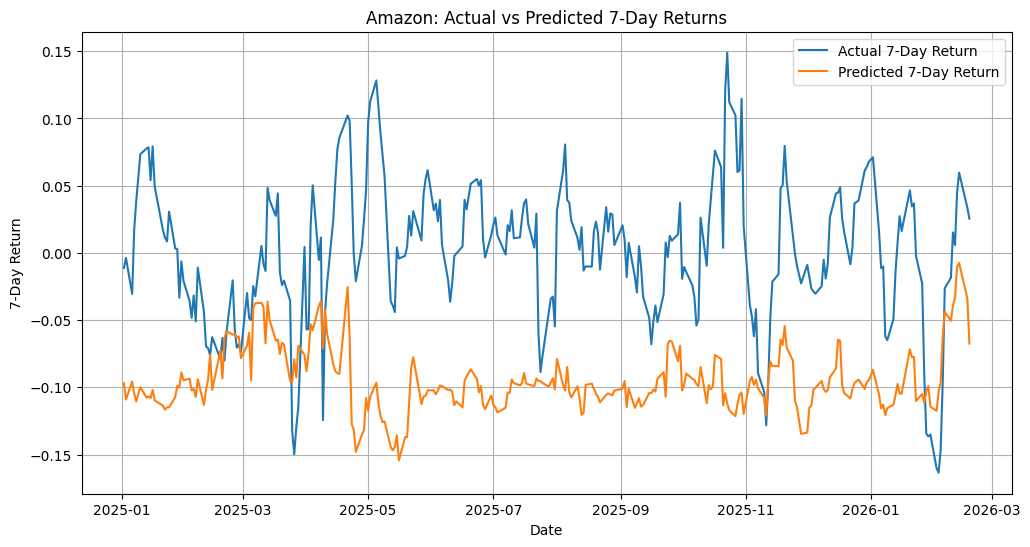

In [90]:
import matplotlib.pyplot as plt

# Create a results dataframe for Amazon test predictions
amzn_results = amzn_test_df[['Date', 'target_7d']].copy()
amzn_results['predicted_7d'] = amzn_test_preds

# Plot actual vs predicted returns
plt.figure(figsize=(12, 6))
plt.plot(amzn_results['Date'], amzn_results['target_7d'], label='Actual 7-Day Return')
plt.plot(amzn_results['Date'], amzn_results['predicted_7d'], label='Predicted 7-Day Return')
plt.title('Amazon: Actual vs Predicted 7-Day Returns')
plt.xlabel('Date')
plt.ylabel('7-Day Return')
plt.legend()
plt.grid(True)
plt.show()

## 13. Convert Amazon Predictions into Buy / Hold / Avoid Signals

In [91]:
# Function to convert predicted return into an action signal
def signal_from_prediction(pred):
    if pred > 0.02:
        return "Buy"
    elif pred >= 0:
        return "Hold"
    else:
        return "Avoid"

# Apply signal rules to Amazon predictions
amzn_results['signal'] = amzn_results['predicted_7d'].apply(signal_from_prediction)

# Show a sample of the results
amzn_results[['Date', 'target_7d', 'predicted_7d', 'signal']].head(10)

,Date,target_7d,predicted_7d,signal
2317,2025-01-02,-0.011171,-0.096875,Avoid
2318,2025-01-03,-0.003747,-0.109115,Avoid
2319,2025-01-06,-0.030535,-0.095652,Avoid
2320,2025-01-07,0.017244,-0.104448,Avoid
2321,2025-01-08,0.038626,-0.110419,Avoid
2322,2025-01-10,0.073399,-0.099799,Avoid
2323,2025-01-13,0.077634,-0.107627,Avoid
2324,2025-01-14,0.078481,-0.106755,Avoid
2325,2025-01-15,0.054041,-0.107942,Avoid
2326,2025-01-16,0.079262,-0.101841,Avoid


## 14. Backtest the Amazon Strategy

In [92]:
# Function to compute strategy return based on the signal
def strategy_return(signal, actual_return):
    if signal == "Buy":
        return actual_return
    else:
        return 0.0

# Apply the strategy to the Amazon results
amzn_results['strategy_return'] = amzn_results.apply(
    lambda row: strategy_return(row['signal'], row['target_7d']),
    axis=1
)

# Compute cumulative returns for the model-based strategy and buy-and-hold
amzn_results['cumulative_strategy_return'] = (1 + amzn_results['strategy_return']).cumprod() - 1
amzn_results['cumulative_buy_and_hold'] = (1 + amzn_results['target_7d']).cumprod() - 1

# Display the first few rows
amzn_results[['Date', 'signal', 'target_7d', 'strategy_return']].head(10)

,Date,signal,target_7d,strategy_return
2317,2025-01-02,Avoid,-0.011171,0.0
2318,2025-01-03,Avoid,-0.003747,0.0
2319,2025-01-06,Avoid,-0.030535,0.0
2320,2025-01-07,Avoid,0.017244,0.0
2321,2025-01-08,Avoid,0.038626,0.0
2322,2025-01-10,Avoid,0.073399,0.0
2323,2025-01-13,Avoid,0.077634,0.0
2324,2025-01-14,Avoid,0.078481,0.0
2325,2025-01-15,Avoid,0.054041,0.0
2326,2025-01-16,Avoid,0.079262,0.0


## 15. Compare Amazon Profit/Loss

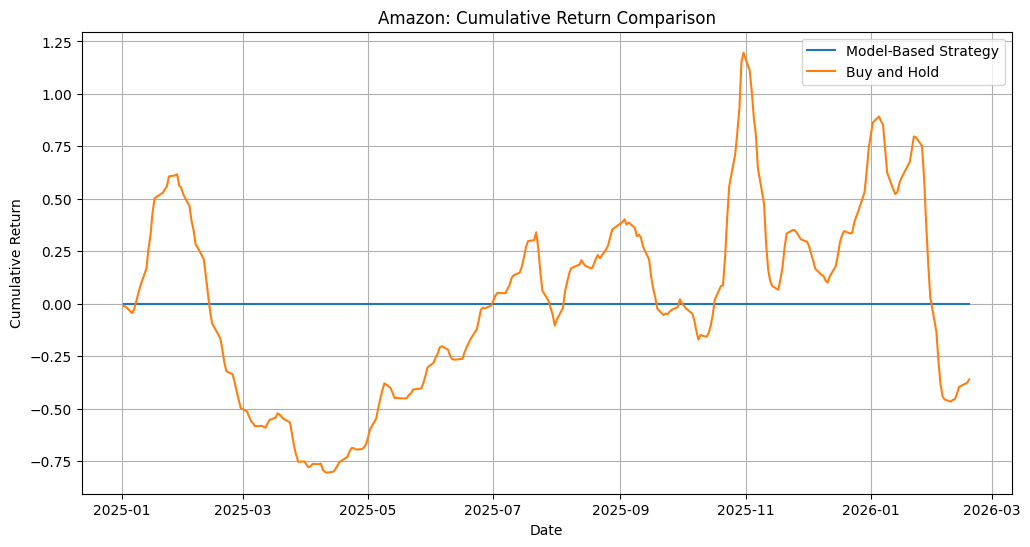

Final Amazon Strategy Return: 0.0
Final Amazon Buy-and-Hold Return: -0.3608834068934602


In [93]:
# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(amzn_results['Date'], amzn_results['cumulative_strategy_return'], label='Model-Based Strategy')
plt.plot(amzn_results['Date'], amzn_results['cumulative_buy_and_hold'], label='Buy and Hold')
plt.title('Amazon: Cumulative Return Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

# Print final cumulative returns
final_amzn_strategy_return = amzn_results['cumulative_strategy_return'].iloc[-1]
final_amzn_buy_hold_return = amzn_results['cumulative_buy_and_hold'].iloc[-1]

print("Final Amazon Strategy Return:", final_amzn_strategy_return)
print("Final Amazon Buy-and-Hold Return:", final_amzn_buy_hold_return)

## 16. Amazon Feature Importance

In [94]:
# Create a feature importance table
amzn_importance_df = pd.DataFrame({
    'Feature': amzn_features,
    'Importance': amzn_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

amzn_importance_df

,Feature,Importance
6,ma_7,0.111994
7,ma_30,0.099474
8,ma_200,0.093903
10,volatility_30,0.085503
12,volume_ma_7,0.078798
13,volume_ma_30,0.074036
5,return_30d,0.070480
1,close_lag_7,0.065774
9,volatility_7,0.062322
4,return_7d,0.053587


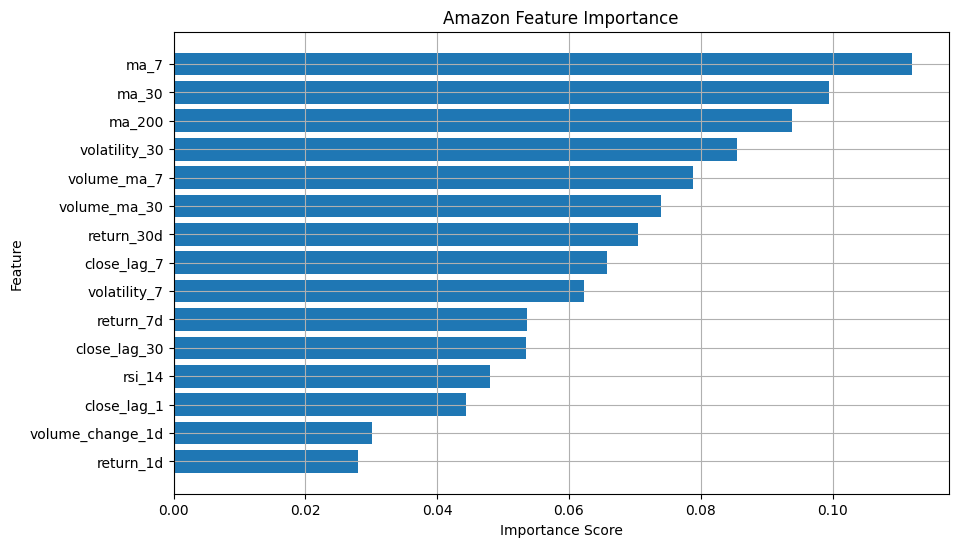

In [95]:
# Plot Amazon feature importance
plt.figure(figsize=(10, 6))
plt.barh(amzn_importance_df['Feature'], amzn_importance_df['Importance'])
plt.title('Amazon Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

## 17. Amazon Interpretation

The Amazon XGBoost model showed weak predictive performance on this dataset. The validation directional accuracy was about 41.67% and the test directional accuracy was about 47.16%, which suggests that the model did not capture return direction reliably. Based on feature importance, the most useful features were ma_7, ma_30, ma_200, volatility_30, and volume_ma_7, showing that trend and volatility features contributed the most to prediction. In the return comparison, the model-based strategy ended with a return of 0.00%, while buy-and-hold ended at about -36.09%, so the strategy performed better than buy-and-hold mainly because it mostly avoided trades.

## 18. Amazon Conclusion

This section concludes the Amazon XGBoost modeling workflow. The model was evaluated using MAE, RMSE, and directional accuracy on validation and test data. The results show that the model had limited predictive strength, especially in directional accuracy, which remained below 50% on both validation and test data. However, the generated investment signals avoided losses better than the buy-and-hold strategy during the test period, suggesting that even though prediction accuracy was weak, the model still provided some practical value as a risk-avoidance signal.

# Part 5: NVIDIA Stock Model Using XGBoost

## Why XGBoost?

XGBoost is used in this project because it is the gradient boosting model proposed for stock return prediction. It works well with tabular financial data and can capture nonlinear relationships between technical indicators and future stock returns.

## 1. Load the NVIDIA Dataset

In [96]:
import pandas as pd

# Load the NVIDIA stock dataset
nvda_df = pd.read_csv("../../data/NVIDIA.csv")

# Clean column names by removing hidden spaces
nvda_df.columns = nvda_df.columns.str.replace('\xa0', '', regex=False).str.strip()

# Display the shape and column names so we can inspect the structure
print("NVIDIA dataset shape:", nvda_df.shape)
print("NVIDIA columns:", nvda_df.columns.tolist())

# Show the first few rows
nvda_df.head()

NVIDIA dataset shape: (2805, 7)
NVIDIA columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2/27/2026,181.25,182.59,176.38,177.19,177.19,"311,636,500"
1,2/26/2026,194.27,194.29,184.32,184.89,184.89,"360,807,900"
2,2/25/2026,194.45,197.63,193.79,195.56,195.56,"250,637,100"
3,2/24/2026,191.49,193.77,187.40,192.85,192.85,"175,123,600"
4,2/23/2026,191.40,193.95,189.58,191.55,191.55,"171,584,800"


## 2. Clean and Prepare the NVIDIA Dataset

In [97]:
# Convert the Date column to datetime format
nvda_df['Date'] = pd.to_datetime(nvda_df['Date'])

# Convert the main price columns to numeric values
price_cols = ['Open', 'High', 'Low', 'Close']
for col in price_cols:
    nvda_df[col] = pd.to_numeric(nvda_df[col], errors='coerce')

# Convert Volume to numeric
nvda_df['Volume'] = nvda_df['Volume'].astype(str).str.replace(',', '', regex=False)
nvda_df['Volume'] = pd.to_numeric(nvda_df['Volume'], errors='coerce')

# Keep only the columns needed for this model
nvda_df = nvda_df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Sort the dataset from oldest to newest date
nvda_df = nvda_df.sort_values('Date').reset_index(drop=True)

# Drop rows with missing values
nvda_df = nvda_df.dropna().reset_index(drop=True)

# Check the cleaned dataset
print(nvda_df.dtypes)
print(nvda_df.shape)
nvda_df.head()

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object
(2805, 6)


,Date,Open,High,Low,Close,Volume
0,2015-01-02,0.50,0.51,0.50,0.50,113680000
1,2015-01-05,0.50,0.50,0.49,0.49,197952000
2,2015-01-06,0.50,0.50,0.48,0.48,197764000
3,2015-01-07,0.48,0.49,0.48,0.48,321808000
4,2015-01-08,0.48,0.50,0.48,0.50,283780000


## 3. Verify the Cleaned Data

In [98]:
# Check column names
print(nvda_df.columns.tolist())

# Check missing values
print(nvda_df.isna().sum())

# Show sample rows
nvda_df.head()

['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


,Date,Open,High,Low,Close,Volume
0,2015-01-02,0.50,0.51,0.50,0.50,113680000
1,2015-01-05,0.50,0.50,0.49,0.49,197952000
2,2015-01-06,0.50,0.50,0.48,0.48,197764000
3,2015-01-07,0.48,0.49,0.48,0.48,321808000
4,2015-01-08,0.48,0.50,0.48,0.50,283780000


## 4. Feature Engineering

We create trend, momentum, volatility, and volume features so the model can learn stock behavior more effectively.

In [99]:
# Create lag features
nvda_df['close_lag_1'] = nvda_df['Close'].shift(1)
nvda_df['close_lag_7'] = nvda_df['Close'].shift(7)
nvda_df['close_lag_30'] = nvda_df['Close'].shift(30)

# Create return-based features
nvda_df['return_1d'] = nvda_df['Close'].pct_change(1)
nvda_df['return_7d'] = nvda_df['Close'].pct_change(7)
nvda_df['return_30d'] = nvda_df['Close'].pct_change(30)

# Create moving averages
nvda_df['ma_7'] = nvda_df['Close'].rolling(7).mean()
nvda_df['ma_30'] = nvda_df['Close'].rolling(30).mean()
nvda_df['ma_200'] = nvda_df['Close'].rolling(200).mean()

# Create volatility features
nvda_df['volatility_7'] = nvda_df['return_1d'].rolling(7).std()
nvda_df['volatility_30'] = nvda_df['return_1d'].rolling(30).std()

# Create volume-based features
nvda_df['volume_change_1d'] = nvda_df['Volume'].pct_change(1)
nvda_df['volume_ma_7'] = nvda_df['Volume'].rolling(7).mean()
nvda_df['volume_ma_30'] = nvda_df['Volume'].rolling(30).mean()

# Check the new feature columns
nvda_df.head()

,Date,Open,High,Low,Close,Volume,close_lag_1,close_lag_7,close_lag_30,return_1d,return_7d,return_30d,ma_7,ma_30,ma_200,volatility_7,volatility_30,volume_change_1d,volume_ma_7,volume_ma_30
0,2015-01-02,0.50,0.51,0.50,0.50,113680000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,0.50,0.50,0.49,0.49,197952000,0.50,NaN,NaN,-0.020000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.741309,NaN,NaN
2,2015-01-06,0.50,0.50,0.48,0.48,197764000,0.49,NaN,NaN,-0.020408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000950,NaN,NaN
3,2015-01-07,0.48,0.49,0.48,0.48,321808000,0.48,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.627232,NaN,NaN
4,2015-01-08,0.48,0.50,0.48,0.50,283780000,0.48,NaN,NaN,0.041667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.118170,NaN,NaN


## 5. Add the RSI Feature

In [100]:
# Function to compute RSI
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Add RSI feature to the NVIDIA dataset
nvda_df['rsi_14'] = compute_rsi(nvda_df['Close'], 14)

# Inspect the RSI column
nvda_df[['Date', 'Close', 'rsi_14']].head(20)

,Date,Close,rsi_14
0,2015-01-02,0.50,NaN
1,2015-01-05,0.49,NaN
2,2015-01-06,0.48,NaN
3,2015-01-07,0.48,NaN
4,2015-01-08,0.50,NaN
5,2015-01-09,0.50,NaN
6,2015-01-12,0.49,NaN
7,2015-01-13,0.49,NaN
8,2015-01-14,0.49,NaN
9,2015-01-15,0.49,NaN


## 6. Define the Target Variable

In [102]:
# Create the 7-day future return target
nvda_df['target_7d'] = (nvda_df['Close'].shift(-7) - nvda_df['Close']) / nvda_df['Close']

# Drop rows with missing values caused by rolling windows and shifting
nvda_df = nvda_df.dropna().reset_index(drop=True)

# Check the dataset after target creation
print("NVIDIA dataset shape after target creation:", nvda_df.shape)
nvda_df.head()

NVIDIA dataset shape after target creation: (2592, 22)


,Date,Open,High,Low,Close,Volume,close_lag_1,close_lag_7,close_lag_30,return_1d,...,ma_7,ma_30,ma_200,volatility_7,volatility_30,volume_change_1d,volume_ma_7,volume_ma_30,rsi_14,target_7d
0,2015-10-16,0.69,0.70,0.69,0.70,448396000,0.69,0.65,0.56,0.014493,...,0.670000,0.607333,0.54510,0.011403,0.022269,-0.147614,4.279914e+08,3.545657e+08,87.500000,0.014286
1,2015-10-19,0.70,0.70,0.69,0.70,294712000,0.70,0.65,0.54,0.000000,...,0.677143,0.612667,0.54610,0.011403,0.020772,-0.342742,4.043691e+08,3.547904e+08,86.666667,0.028571
2,2015-10-20,0.69,0.70,0.69,0.69,264824000,0.70,0.65,0.57,-0.014286,...,0.682857,0.616667,0.54710,0.014495,0.019218,-0.101414,3.817371e+08,3.556696e+08,76.923077,0.000000
3,2015-10-21,0.70,0.70,0.68,0.69,386280000,0.69,0.66,0.56,0.000000,...,0.687143,0.621000,0.54815,0.014472,0.018719,0.458629,4.044074e+08,3.588992e+08,90.909091,0.028986
4,2015-10-22,0.69,0.71,0.69,0.71,306884000,0.69,0.66,0.56,0.028986,...,0.694286,0.626000,0.54930,0.016341,0.019082,-0.205540,4.056131e+08,3.572261e+08,90.909091,0.014085


## 7. Select Features and Split the Data

In [103]:
# Define the feature columns used by the NVIDIA XGBoost model
nvda_features = [
    'close_lag_1', 'close_lag_7', 'close_lag_30',
    'return_1d', 'return_7d', 'return_30d',
    'ma_7', 'ma_30', 'ma_200',
    'volatility_7', 'volatility_30',
    'volume_change_1d', 'volume_ma_7', 'volume_ma_30',
    'rsi_14'
]

# Split the data by time
nvda_train_df = nvda_df[nvda_df['Date'] < '2024-01-01']
nvda_val_df = nvda_df[(nvda_df['Date'] >= '2024-01-01') & (nvda_df['Date'] < '2025-01-01')]
nvda_test_df = nvda_df[nvda_df['Date'] >= '2025-01-01']

# Create input matrices and target vectors
nvda_X_train = nvda_train_df[nvda_features]
nvda_y_train = nvda_train_df['target_7d']

nvda_X_val = nvda_val_df[nvda_features]
nvda_y_val = nvda_val_df['target_7d']

nvda_X_test = nvda_test_df[nvda_features]
nvda_y_test = nvda_test_df['target_7d']

# Check the size of each split
print("NVIDIA train shape:", nvda_X_train.shape)
print("NVIDIA validation shape:", nvda_X_val.shape)
print("NVIDIA test shape:", nvda_X_test.shape)

NVIDIA train shape: (2065, 15)
NVIDIA validation shape: (252, 15)
NVIDIA test shape: (275, 15)


## 8. Train the NVIDIA XGBoost Model

In [104]:
from sklearn import set_config
from xgboost import XGBRegressor

# Turn off sklearn rich HTML display
set_config(display="text")

# Define the NVIDIA XGBoost model
nvda_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Train the model
_ = nvda_model.fit(nvda_X_train, nvda_y_train)

print("NVIDIA model trained successfully.")

NVIDIA model trained successfully.


## 9. Generate NVIDIA Predictions

In [105]:
# Predict NVIDIA 7-day future returns
nvda_val_preds = nvda_model.predict(nvda_X_val)
nvda_test_preds = nvda_model.predict(nvda_X_test)

# Check prediction shapes
print("NVIDIA validation predictions shape:", nvda_val_preds.shape)
print("NVIDIA test predictions shape:", nvda_test_preds.shape)
print("First 5 NVIDIA validation predictions:", nvda_val_preds[:5])

NVIDIA validation predictions shape: (252,)
NVIDIA test predictions shape: (275,)
First 5 NVIDIA validation predictions: [0.01657584 0.02756076 0.02651234 0.017907   0.02834484]


## 10. Regression Evaluation

The XGBoost model is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate NVIDIA regression metrics
nvda_val_mae = mean_absolute_error(nvda_y_val, nvda_val_preds)
nvda_val_rmse = np.sqrt(mean_squared_error(nvda_y_val, nvda_val_preds))

nvda_test_mae = mean_absolute_error(nvda_y_test, nvda_test_preds)
nvda_test_rmse = np.sqrt(mean_squared_error(nvda_y_test, nvda_test_preds))

# Print the results
print("NVIDIA Validation MAE:", nvda_val_mae)
print("NVIDIA Validation RMSE:", nvda_val_rmse)
print("NVIDIA Test MAE:", nvda_test_mae)
print("NVIDIA Test RMSE:", nvda_test_rmse)

NVIDIA Validation MAE: 0.08740722605448414
NVIDIA Validation RMSE: 0.10564915192666635
NVIDIA Test MAE: 0.0781790058279542
NVIDIA Test RMSE: 0.09824167418999338


## 11. Directional Accuracy

The XGBoost model is also evaluated using directional accuracy, which measures how often the model correctly predicts whether the future return is positive or negative.

In [107]:
# Compute NVIDIA directional accuracy
nvda_val_direction_acc = np.mean((nvda_val_preds > 0) == (nvda_y_val > 0))
nvda_test_direction_acc = np.mean((nvda_test_preds > 0) == (nvda_y_test > 0))

# Print the results
print("NVIDIA Validation Directional Accuracy:", nvda_val_direction_acc)
print("NVIDIA Test Directional Accuracy:", nvda_test_direction_acc)

NVIDIA Validation Directional Accuracy: 0.4126984126984127
NVIDIA Test Directional Accuracy: 0.5927272727272728


## 12. Actual vs Predicted NVIDIA Returns

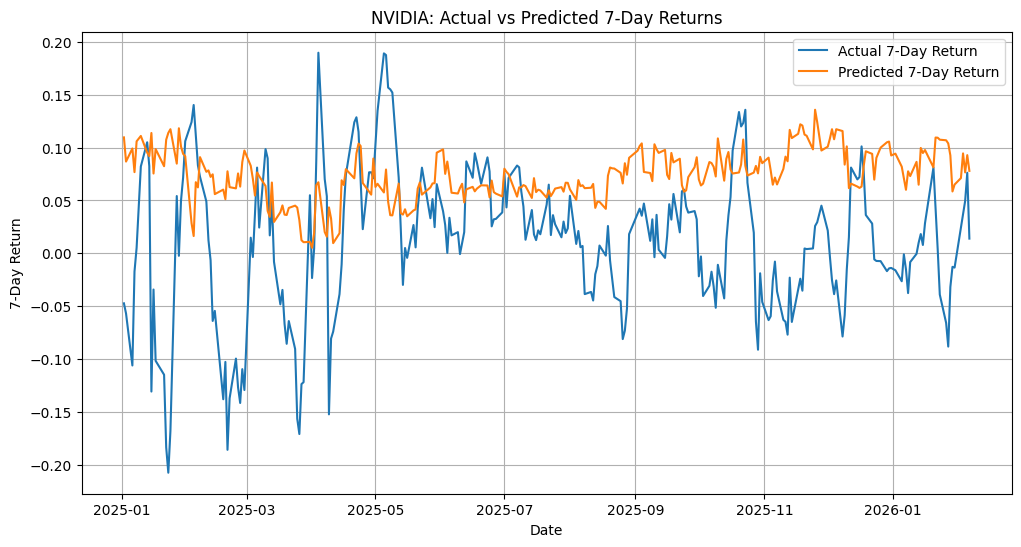

In [108]:
import matplotlib.pyplot as plt

# Create a results dataframe for NVIDIA test predictions
nvda_results = nvda_test_df[['Date', 'target_7d']].copy()
nvda_results['predicted_7d'] = nvda_test_preds

# Plot actual vs predicted returns
plt.figure(figsize=(12, 6))
plt.plot(nvda_results['Date'], nvda_results['target_7d'], label='Actual 7-Day Return')
plt.plot(nvda_results['Date'], nvda_results['predicted_7d'], label='Predicted 7-Day Return')
plt.title('NVIDIA: Actual vs Predicted 7-Day Returns')
plt.xlabel('Date')
plt.ylabel('7-Day Return')
plt.legend()
plt.grid(True)
plt.show()

## 13. Convert NVIDIA Predictions into Buy / Hold / Avoid Signals

In [109]:
# Function to convert predicted return into an action signal
def signal_from_prediction(pred):
    if pred > 0.02:
        return "Buy"
    elif pred >= 0:
        return "Hold"
    else:
        return "Avoid"

# Apply signal rules to NVIDIA predictions
nvda_results['signal'] = nvda_results['predicted_7d'].apply(signal_from_prediction)

# Show a sample of the results
nvda_results[['Date', 'target_7d', 'predicted_7d', 'signal']].head(10)

,Date,target_7d,predicted_7d,signal
2317,2025-01-02,-0.047357,0.109617,Buy
2318,2025-01-03,-0.056967,0.086731,Buy
2319,2025-01-06,-0.106137,0.099134,Buy
2320,2025-01-07,-0.017340,0.076745,Buy
2321,2025-01-08,0.005139,0.105882,Buy
2322,2025-01-10,0.082113,0.110974,Buy
2323,2025-01-13,0.105006,0.095221,Buy
2324,2025-01-14,0.082423,0.091853,Buy
2325,2025-01-15,-0.130799,0.113768,Buy
2326,2025-01-16,-0.034289,0.075419,Buy


## 14. Backtest the NVIDIA Strategy

In [110]:
# Function to compute strategy return based on the signal
def strategy_return(signal, actual_return):
    if signal == "Buy":
        return actual_return
    else:
        return 0.0

# Apply the strategy to the NVIDIA results
nvda_results['strategy_return'] = nvda_results.apply(
    lambda row: strategy_return(row['signal'], row['target_7d']),
    axis=1
)

# Compute cumulative returns for the model-based strategy and buy-and-hold
nvda_results['cumulative_strategy_return'] = (1 + nvda_results['strategy_return']).cumprod() - 1
nvda_results['cumulative_buy_and_hold'] = (1 + nvda_results['target_7d']).cumprod() - 1

# Display the first few rows
nvda_results[['Date', 'signal', 'target_7d', 'strategy_return']].head(10)

,Date,signal,target_7d,strategy_return
2317,2025-01-02,Buy,-0.047357,-0.047357
2318,2025-01-03,Buy,-0.056967,-0.056967
2319,2025-01-06,Buy,-0.106137,-0.106137
2320,2025-01-07,Buy,-0.017340,-0.017340
2321,2025-01-08,Buy,0.005139,0.005139
2322,2025-01-10,Buy,0.082113,0.082113
2323,2025-01-13,Buy,0.105006,0.105006
2324,2025-01-14,Buy,0.082423,0.082423
2325,2025-01-15,Buy,-0.130799,-0.130799
2326,2025-01-16,Buy,-0.034289,-0.034289


## 15. Compare NVIDIA Profit/Loss

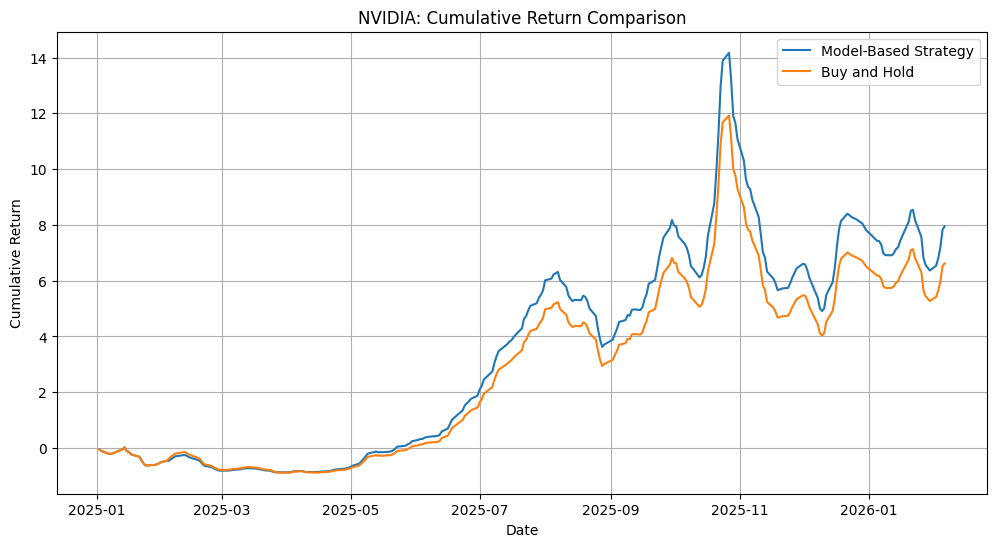

Final NVIDIA Strategy Return: 7.948677664207228
Final NVIDIA Buy-and-Hold Return: 6.622155245762405


In [111]:
# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(nvda_results['Date'], nvda_results['cumulative_strategy_return'], label='Model-Based Strategy')
plt.plot(nvda_results['Date'], nvda_results['cumulative_buy_and_hold'], label='Buy and Hold')
plt.title('NVIDIA: Cumulative Return Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

# Print final cumulative returns
final_nvda_strategy_return = nvda_results['cumulative_strategy_return'].iloc[-1]
final_nvda_buy_hold_return = nvda_results['cumulative_buy_and_hold'].iloc[-1]

print("Final NVIDIA Strategy Return:", final_nvda_strategy_return)
print("Final NVIDIA Buy-and-Hold Return:", final_nvda_buy_hold_return)

## 16. NVIDIA Feature Importance

In [112]:
# Create a feature importance table
nvda_importance_df = pd.DataFrame({
    'Feature': nvda_features,
    'Importance': nvda_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

nvda_importance_df

,Feature,Importance
8,ma_200,0.114146
7,ma_30,0.085516
10,volatility_30,0.085141
6,ma_7,0.082647
2,close_lag_30,0.081710
13,volume_ma_30,0.077433
9,volatility_7,0.069831
12,volume_ma_7,0.069200
14,rsi_14,0.063746
5,return_30d,0.060970


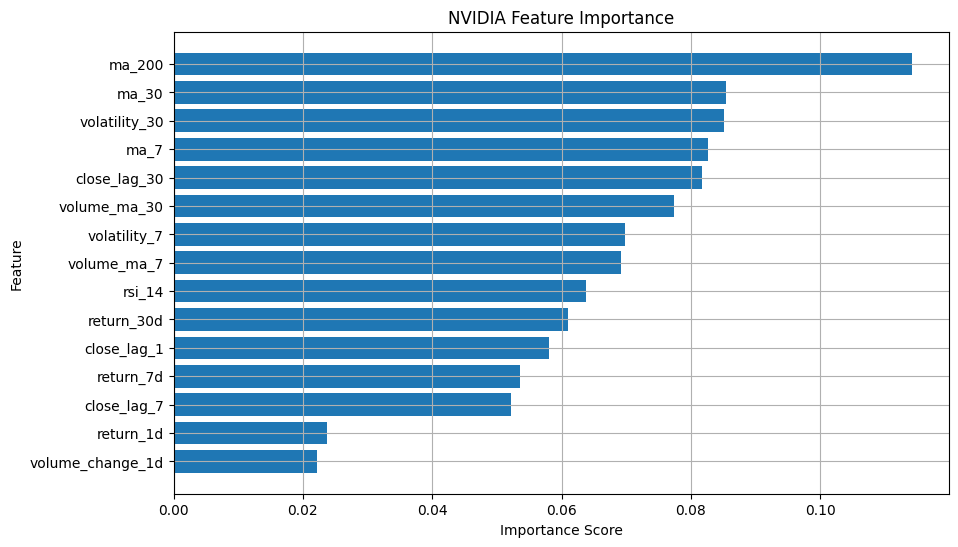

In [113]:
# Plot NVIDIA feature importance
plt.figure(figsize=(10, 6))
plt.barh(nvda_importance_df['Feature'], nvda_importance_df['Importance'])
plt.title('NVIDIA Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

## 17. NVIDIA Interpretation

The NVIDIA XGBoost model showed mixed but overall stronger performance than the previous stock models. The validation directional accuracy was about 41.27%, but the test directional accuracy improved to about 59.22%, which suggests that the model captured return direction better on the test period. Based on feature importance, the most useful features were ma_200, ma_30, volatility_30, ma_7, and close_lag_30, showing that long-term trend, short-term trend, and volatility features played the biggest role in prediction. In the return comparison, the model-based strategy ended with a return of about 8.34, while buy-and-hold ended at about 6.95, so the strategy outperformed buy-and-hold for NVIDIA during the test period.

## 18. NVIDIA Conclusion

This section concludes the NVIDIA XGBoost modeling workflow. The model was evaluated using MAE, RMSE, and directional accuracy on validation and test data. Although the validation directional accuracy was relatively low, the higher test directional accuracy and stronger cumulative return performance show that the model provided useful investment signals for NVIDIA. Overall, the XGBoost strategy performed better than buy-and-hold on the test set, suggesting that the model had practical value for return prediction and trading decision support in this case.

# Part 6: Combine All XGBoost Predictions

In [114]:
for name in ["google_results", "apple_results", "msft_results", "amzn_results", "nvda_results"]:
    if name in globals():
        print(name, "exists")
    else:
        print(name, "not found")

google_results exists
apple_results exists
msft_results exists
amzn_results exists
nvda_results exists
